# Telecom Churn Case Study

#### Created by: Raja Kalavala


## Contents
1. [Problem Statement](#problem-statement)
2. [Objectives](#objectives)
3. [Business Goals](#business-goals)
4. [Data Reading and Understanding](#data-reading-and-understanding)
5. [Data Preparation and Cleaning](#data-preparation-and-cleaning)
    * [Find the columns with Single unique values](#find-the-columns-with-single-unique-values)
    * [Drop Date Column](#drop-date-column)
    * [Handle Missing Values](#handle-missing-values)
    * [Deriving New Features](#derive-new-features)
    * [Analyse Target Variable](#analyse-target-variable)
    * [Impute missing values using KNN Imputer](#impute-missing-values-using-knn-imputer)
    
6. [Common Methods](#common-methods)
7. [Exploratory Data Analysis](#exploratory-data-analysis)
8. [Dummy Variable Creation ](#dummy-variable-creation)
9. [Outlier Treatment](#outlier-treatment)
10. [Model Building and Evaluation](#model-building-and-evaluation)
    * [Train Test Split](#train-test-split)
    * [Data Imbalance in target variable](#data-imbalance-in-target-variable)
    * [Feature Scaling](#feature-scaling)
    * [Model Building](#model-building)
11. [Create submission.csv file](#create-submission-csv-file)
12. [Summary](#summary)
13. [Business Recommendations](#business-recommendations)



### Problem Statement

In the telecom industry, customers are able to choose from multiple service providers and actively switch from one operator to another. In this highly competitive market, the telecommunications industry experiences an average of 15-25% annual churn rate. Given the fact that it costs 5-10 times more to acquire a new customer than to retain an existing one, customer retention has now become even more important than customer acquisition.

For many incumbent operators, retaining high profitable customers is the number one business goal. To reduce customer churn, telecom companies need to predict which customers are at high risk of churn. In this project, we will analyze customer-level data of a leading telecom firm, build predictive models to identify customers at high risk of churn.


### Objectives

- Predict whether a high-value customer will churn in the near future.
- Identify key variables that are strong predictors of churn, potentially indicating reasons why customers switch networks.
- Recommend strategies to help manage and reduce customer churn.


### Business Goals
- Use the predictive model to focus on retaining high-value customers by taking timely actions, such as offering special plans or discounts.
- Gain a deeper understanding of factors influencing customer churn, helping the business make data-driven decisions.
- Evaluate the model’s performance with accuracy as the primary metric, while also considering precision, recall, and other metrics for specific business needs.


## 1. Data Reading and Understanding

In [820]:
## Import all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from imblearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

In [ ]:
## Read the data and print the shape
data = pd.read_csv('train.csv')
unseen_data = pd.read_csv('test.csv')
data_dict = pd.read_csv('data_dictionary.csv')
sample = pd.read_csv('sample.csv')

print(data.shape)
print(unseen_data.shape)
print(data_dict.shape)
print(sample.shape)

(69999, 172)
(30000, 171)
(36, 2)
(30000, 2)


In [822]:
## Inspect the Dictionary
data_dict

,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belo...
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile...
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


In [823]:
## Inspect the train data
data.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 172 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    id                        int64  
 1    circle_id                 int64  
 2    loc_og_t2o_mou            float64
 3    std_og_t2o_mou            float64
 4    loc_ic_t2o_mou            float64
 5    last_date_of_month_6      object 
 6    last_date_of_month_7      object 
 7    last_date_of_month_8      object 
 8    arpu_6                    float64
 9    arpu_7                    float64
 10   arpu_8                    float64
 11   onnet_mou_6               float64
 12   onnet_mou_7               float64
 13   onnet_mou_8               float64
 14   offnet_mou_6              float64
 15   offnet_mou_7              float64
 16   offnet_mou_8              float64
 17   roam_ic_mou_6             float64
 18   roam_ic_mou_7             float64
 19   roam_ic_mou_8             float64
 20   roam

In [824]:
data.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


In [825]:
## Value count the target variable
data['churn_probability'].value_counts()

churn_probability
0    62867
1     7132
Name: count, dtype: int64

In [826]:
## Summary of train dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,69999.0,34999.000000,20207.115084,0.0,17499.5,34999.0,52498.5,69998.00
circle_id,69999.0,109.000000,0.000000,109.0,109.0,109.0,109.0,109.00
loc_og_t2o_mou,69297.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
std_og_t2o_mou,69297.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
loc_ic_t2o_mou,69297.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...
aon,69999.0,1220.639709,952.426321,180.0,468.0,868.0,1813.0,4337.00
aug_vbc_3g,69999.0,68.108597,269.328659,0.0,0.0,0.0,0.0,12916.22
jul_vbc_3g,69999.0,65.935830,267.899034,0.0,0.0,0.0,0.0,9165.60
jun_vbc_3g,69999.0,60.076740,257.226810,0.0,0.0,0.0,0.0,11166.21


In [827]:
# Create backup of the data
telecom_train = data.copy()
telecom_test = unseen_data.copy()

<div class="alert alert-block alert-info">
<h3>Analysis:</h3>

1. The dataset has 172 columns in `train.csv`, which include a mix of numerical and categorical data. <br>
2. The target variable is **churn_probability**, which has a value of 0 or 1 indicating whether a customer churned (1) or not (0). <br>
3. The columns include customer usage patterns, roaming and call metrics, recharge details, and possibly some customer demographic information.<br>
4. Many columns seem to represent different metrics related to customer in the form of Acronyms.<br>
5. The `data_dictionary.csv` file provides definitions of these acronyms. For instance: 
    * **std_og_mou_6** translates to standard outgoing minutes of usage in June.
    * **roam_og_mou_8** refers to roaming outgoing minutes of usage in August.
6. The target variable, **churn_probability**, appears balanced based on preliminary analysis. However, if there’s a significant imbalance, it might affect the model performance and would need handling.

</div>

## 2. Data Preparation and Cleaning

In [828]:
# Remove the id column since it is unique to each observation
data = data.drop('id', axis=1)
data.head()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,7.527,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,42.953,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,0.000,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,111.095,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,101.565,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


### 2.1 Find the columns with Single unique values

In [829]:
# Print list columns with single value
cols_with_single_value = []
for col in data.columns:
    if data[col].nunique() == 1:
        cols_with_single_value.append(col)

print(cols_with_single_value)

['circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou', 'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8', 'std_og_t2c_mou_6', 'std_og_t2c_mou_7', 'std_og_t2c_mou_8', 'std_ic_t2o_mou_6', 'std_ic_t2o_mou_7', 'std_ic_t2o_mou_8']


In [830]:
data[cols_with_single_value].describe()

,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8
count,69999.0,69297.0,69297.0,69297.0,67231.0,67312.0,66296.0,67231.0,67312.0,66296.0
mean,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [831]:
# Print value counts of each single value column
for col in cols_with_single_value:
    print(data[col].value_counts(dropna=False))
    print('------------------------------------\n')


circle_id
109    69999
Name: count, dtype: int64
------------------------------------

loc_og_t2o_mou
0.0    69297
NaN      702
Name: count, dtype: int64
------------------------------------

std_og_t2o_mou
0.0    69297
NaN      702
Name: count, dtype: int64
------------------------------------

loc_ic_t2o_mou
0.0    69297
NaN      702
Name: count, dtype: int64
------------------------------------

last_date_of_month_6
6/30/2014    69999
Name: count, dtype: int64
------------------------------------

last_date_of_month_7
7/31/2014    69600
NaN            399
Name: count, dtype: int64
------------------------------------

last_date_of_month_8
8/31/2014    69266
NaN            733
Name: count, dtype: int64
------------------------------------

std_og_t2c_mou_6
0.0    67231
NaN     2768
Name: count, dtype: int64
------------------------------------

std_og_t2c_mou_7
0.0    67312
NaN     2687
Name: count, dtype: int64
------------------------------------

std_og_t2c_mou_8
0.0    66296
NaN 

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* We can Remove these column as it has only one unique value and does not provide any useful information to the model.

In [832]:
# Drop columns with single value from train and test dataset
data.drop(cols_with_single_value, axis=1, inplace=True)
unseen_data.drop(cols_with_single_value, axis=1, inplace=True)

In [833]:
print(data.shape)
print(unseen_data.shape)

(69999, 158)
(30000, 158)


### 2.2 Drop Date Column

In [834]:
date_cols = ['date_of_last_rech_6',
            'date_of_last_rech_7',
            'date_of_last_rech_8',
            'date_of_last_rech_data_6',
            'date_of_last_rech_data_7',
            'date_of_last_rech_data_8',
            ]

In [835]:
# Dropping date columns as they are not useful for our analysis from the training and test set
data.drop(columns=date_cols, axis=1, inplace=True)
unseen_data.drop(columns=date_cols, axis=1, inplace=True)

In [836]:
print(data.shape)
print(unseen_data.shape)

(69999, 152)
(30000, 152)


### 2.3 Handle Missing Values

In [837]:
### Check for columns with more than 70% missing values in the training dataset
mv_train_set = round(100*(data.isna().sum(axis=0)/data.shape[0]), 2)
mv_train_set[mv_train_set > 70].sort_values(ascending=False)

total_rech_data_6     74.90
arpu_3g_6             74.90
max_rech_data_6       74.90
fb_user_6             74.90
count_rech_2g_6       74.90
night_pck_user_6      74.90
count_rech_3g_6       74.90
arpu_2g_6             74.90
av_rech_amt_data_6    74.90
fb_user_7             74.48
night_pck_user_7      74.48
arpu_2g_7             74.48
arpu_3g_7             74.48
av_rech_amt_data_7    74.48
total_rech_data_7     74.48
count_rech_3g_7       74.48
count_rech_2g_7       74.48
max_rech_data_7       74.48
av_rech_amt_data_8    73.69
count_rech_3g_8       73.69
arpu_3g_8             73.69
count_rech_2g_8       73.69
arpu_2g_8             73.69
max_rech_data_8       73.69
night_pck_user_8      73.69
total_rech_data_8     73.69
fb_user_8             73.69
dtype: float64

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

There are numerous variables with consistent percentages of missing data, suggesting a pattern of meaningful absence. Our strategy involves grouping similar data for analysis:

1. Grouping and treating missing values for 'recharge-related' data.
2. Grouping and treating missing values for 'ARPU' data.
3. Conducting missing value treatment on categorical columns.

##### Recharge Column

In [838]:
# Column with recharge information
recharge_col = data.columns[data.columns.str.contains('_rech_')]
print(recharge_col)
print(len(recharge_col))

Index(['total_rech_num_6', 'total_rech_num_7', 'total_rech_num_8',
       'total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8',
       'max_rech_amt_6', 'max_rech_amt_7', 'max_rech_amt_8',
       'total_rech_data_6', 'total_rech_data_7', 'total_rech_data_8',
       'max_rech_data_6', 'max_rech_data_7', 'max_rech_data_8',
       'count_rech_2g_6', 'count_rech_2g_7', 'count_rech_2g_8',
       'count_rech_3g_6', 'count_rech_3g_7', 'count_rech_3g_8',
       'av_rech_amt_data_6', 'av_rech_amt_data_7', 'av_rech_amt_data_8'],
      dtype='object')
24


In [839]:
# Replace NaN value in recharge_col with 0 in training and test dataset
data[recharge_col] = data[recharge_col].fillna(0)
print(data[recharge_col].isnull().sum())

unseen_data[recharge_col] = unseen_data[recharge_col].fillna(0)
print(unseen_data[recharge_col].isnull().sum())

total_rech_num_6      0
total_rech_num_7      0
total_rech_num_8      0
total_rech_amt_6      0
total_rech_amt_7      0
total_rech_amt_8      0
max_rech_amt_6        0
max_rech_amt_7        0
max_rech_amt_8        0
total_rech_data_6     0
total_rech_data_7     0
total_rech_data_8     0
max_rech_data_6       0
max_rech_data_7       0
max_rech_data_8       0
count_rech_2g_6       0
count_rech_2g_7       0
count_rech_2g_8       0
count_rech_3g_6       0
count_rech_3g_7       0
count_rech_3g_8       0
av_rech_amt_data_6    0
av_rech_amt_data_7    0
av_rech_amt_data_8    0
dtype: int64
total_rech_num_6      0
total_rech_num_7      0
total_rech_num_8      0
total_rech_amt_6      0
total_rech_amt_7      0
total_rech_amt_8      0
max_rech_amt_6        0
max_rech_amt_7        0
max_rech_amt_8        0
total_rech_data_6     0
total_rech_data_7     0
total_rech_data_8     0
max_rech_data_6       0
max_rech_data_7       0
max_rech_data_8       0
count_rech_2g_6       0
count_rech_2g_7       0
cou

##### ARPU Columns

In [840]:
# Columns with 'arpu' information
arpu_cols = data.columns[data.columns.str.contains('arpu_')]
print(arpu_cols)
print(len(arpu_cols))

Index(['arpu_6', 'arpu_7', 'arpu_8', 'arpu_3g_6', 'arpu_3g_7', 'arpu_3g_8',
       'arpu_2g_6', 'arpu_2g_7', 'arpu_2g_8'],
      dtype='object')
9


In [841]:
# Replace NaN in arpu columns with 0 in training and test sets
data[arpu_cols] = data[arpu_cols].fillna(0)
print(data[arpu_cols].isna().sum())

unseen_data[arpu_cols] = unseen_data[arpu_cols].fillna(0)
print(unseen_data[arpu_cols].isna().sum())

arpu_6       0
arpu_7       0
arpu_8       0
arpu_3g_6    0
arpu_3g_7    0
arpu_3g_8    0
arpu_2g_6    0
arpu_2g_7    0
arpu_2g_8    0
dtype: int64
arpu_6       0
arpu_7       0
arpu_8       0
arpu_3g_6    0
arpu_3g_7    0
arpu_3g_8    0
arpu_2g_6    0
arpu_2g_7    0
arpu_2g_8    0
dtype: int64


##### Categorical Columns

In [842]:
# Generate list of categorical columns
categorical_col = ['night_pck_user_6',
            'night_pck_user_7',
            'night_pck_user_8',
            'fb_user_6',
            'fb_user_7',
            'fb_user_8',]
categorical_col

['night_pck_user_6',
 'night_pck_user_7',
 'night_pck_user_8',
 'fb_user_6',
 'fb_user_7',
 'fb_user_8']

In [843]:
# Inspect categorical columns
data[categorical_col].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   night_pck_user_6  17568 non-null  float64
 1   night_pck_user_7  17865 non-null  float64
 2   night_pck_user_8  18417 non-null  float64
 3   fb_user_6         17568 non-null  float64
 4   fb_user_7         17865 non-null  float64
 5   fb_user_8         18417 non-null  float64
dtypes: float64(6)
memory usage: 3.2 MB


#### Step : Imputing missing categorical values

Imputing missing categorical values with a value of -1 facilitates the preservation and identification of missing data while ensuring compatibility with analysis algorithms and maintaining consistency in data encoding.

In [844]:
# Replace NaN values with -1 in categorical columns for both training and test datasets
data[categorical_col] = data[categorical_col].fillna(-1).astype('category')
print(data[categorical_col].isna().sum())

unseen_data[categorical_col] = unseen_data[categorical_col].fillna(-1).astype('category')
print(unseen_data[categorical_col].isna().sum())

night_pck_user_6    0
night_pck_user_7    0
night_pck_user_8    0
fb_user_6           0
fb_user_7           0
fb_user_8           0
dtype: int64
night_pck_user_6    0
night_pck_user_7    0
night_pck_user_8    0
fb_user_6           0
fb_user_7           0
fb_user_8           0
dtype: int64


In [845]:
# Inspect categorical columns after imputing
data[categorical_col].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   night_pck_user_6  69999 non-null  category
 1   night_pck_user_7  69999 non-null  category
 2   night_pck_user_8  69999 non-null  category
 3   fb_user_6         69999 non-null  category
 4   fb_user_7         69999 non-null  category
 5   fb_user_8         69999 non-null  category
dtypes: category(6)
memory usage: 411.1 KB


In [846]:
# Check for columns which have missing values present
mv_train_set[(mv_train_set > 0) & (mv_train_set <= 70)].sort_values(ascending=False)

ic_others_8         5.29
loc_og_t2m_mou_8    5.29
std_og_mou_8        5.29
spl_og_mou_8        5.29
std_og_t2f_mou_8    5.29
                    ... 
std_og_t2f_mou_7    3.84
og_others_7         3.84
std_og_mou_7        3.84
spl_og_mou_7        3.84
isd_og_mou_7        3.84
Length: 81, dtype: float64

In [847]:
# Store missing values columns into a list to be processed later for imputation using the KNN technique
missing_vlaues_list = mv_train_set[(mv_train_set > 0) & (mv_train_set <= 70)].index
print(missing_vlaues_list)

Index(['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6',
       'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7',
       'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8',
       'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8',
       'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8',
       'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8',
       'loc_og_t2c_mou_6', 'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8',
       'loc_og_mou_6', 'loc_og_mou_7', 'loc_og_mou_8', 'std_og_t2t_mou_6',
       'std_og_t2t_mou_7', 'std_og_t2t_mou_8', 'std_og_t2m_mou_6',
       'std_og_t2m_mou_7', 'std_og_t2m_mou_8', 'std_og_t2f_mou_6',
       'std_og_t2f_mou_7', 'std_og_t2f_mou_8', 'std_og_mou_6', 'std_og_mou_7',
       'std_og_mou_8', 'isd_og_mou_6', 'isd_og_mou_7', 'isd_og_mou_8',
       'spl_og_mou_6', 'spl_og_mou_7', 'spl_og_mou_8', 'og_others_6',
       'og_others_7', 'og_others_8', 'loc_ic_t2t_mou_6', 'loc_ic_t2t_mou_7',
       'lo

### 2.4 Deriving New Features


We can evaluate the recharge amounts from June and July and select only top 70% of customers as high value custormers. We can create a new feature named Total Data Recharge Amount by multiplying the values of total_rech_data and av_rech_amt_data, which represents the amount recharged by the customer for data usage.

Total Data Recharge Amount = Total Data Recharge * Average Data Recharge Amount
Created another column for total recharge done Total Amount for the months 6 and 7.

Total Amount = Total Data Recharge Amount + Total Recharge Amount
Additionally, we can compute the Total Average Recharge Amount during the 'Good Phase', which includes months 6 and 7.

Total Average Amount = (Total Data Recharge Amount + Total Recharge Amount) / 2

In [848]:
# Deriving columns for total data recharge amount for the 'Good Phase' in the training dataset
data['total_rech_data_amt_6'] = data['total_rech_data_6'] * data['av_rech_amt_data_6']
data['total_rech_data_amt_7'] = data['total_rech_data_7'] * data['av_rech_amt_data_7']

data['total_amt_6'] = data['total_rech_data_amt_6'] + data['total_rech_amt_6']
data['total_amt_7'] = data['total_rech_data_amt_7'] + data['total_rech_amt_7']

data['total_avg_amt_6_7'] = data[['total_amt_6', 'total_amt_7']].mean(axis=1)
data.shape

(69999, 157)

In [849]:
# Drop the columns which are not so useful columns for high value customers or churn
drop_cols = ['total_rech_data_amt_6', 'total_rech_data_amt_7', 'av_rech_amt_data_6', 'av_rech_amt_data_7',
                  'av_rech_amt_data_8', 'total_rech_data_6', 'total_rech_data_7', 'total_rech_data_8',]

data.drop(drop_cols, axis=1, inplace=True)
data.shape

(69999, 149)

In [850]:
# Deriving columns for total data recharge amount for the 'Good Phase' in the test dataset
unseen_data['total_rech_data_amt_6'] = unseen_data['total_rech_data_6'] * unseen_data['av_rech_amt_data_6']
unseen_data['total_rech_data_amt_7'] = unseen_data['total_rech_data_7'] * unseen_data['av_rech_amt_data_7']

unseen_data['total_amt_6'] = unseen_data['total_rech_data_amt_6'] + unseen_data['total_rech_amt_6']
unseen_data['total_amt_7'] = unseen_data['total_rech_data_amt_7'] + unseen_data['total_rech_amt_7']

unseen_data['total_avg_amt_6_7'] = unseen_data[['total_amt_6', 'total_amt_7']].mean(axis=1)
unseen_data.shape


(30000, 157)

In [851]:
# Dropping the drop_data_cols from the test set
unseen_data.drop(drop_cols, axis=1, inplace=True)
unseen_data.shape

(30000, 149)

In [852]:
data.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,...,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability,total_amt_6,total_amt_7,total_avg_amt_6_7
0,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,0.00,...,-1.0,-1.0,1958,0.0,0.0,0.0,0,77.0,65.0,71.0
1,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,...,1.0,-1.0,710,0.0,0.0,0.0,0,0.0,290.0,145.0
2,60.806,103.176,0.000,0.53,15.93,0.00,53.99,82.05,0.00,0.00,...,-1.0,-1.0,882,0.0,0.0,0.0,0,70.0,120.0,95.0
3,156.362,205.260,111.095,7.26,16.01,0.00,68.76,78.48,50.23,0.00,...,-1.0,-1.0,982,0.0,0.0,0.0,0,160.0,240.0,200.0
4,240.708,128.191,101.565,21.28,4.83,6.13,56.99,38.11,9.63,53.64,...,1.0,1.0,647,0.0,0.0,0.0,0,1515.0,1473.0,1494.0


In [853]:
unseen_data.head()

,id,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,...,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,total_amt_6,total_amt_7,total_avg_amt_6_7
0,69999,91.882,65.330,64.445,31.78,20.23,23.11,60.16,32.16,34.83,...,-1.0,-1.0,-1.0,1692,0.00,0.00,0.00,103.0,90.0,96.5
1,70000,414.168,515.568,360.868,75.51,41.21,19.84,474.34,621.84,394.94,...,-1.0,-1.0,-1.0,2533,0.00,0.00,0.00,500.0,500.0,500.0
2,70001,329.844,434.884,746.239,7.54,7.86,8.40,16.98,45.81,45.04,...,-1.0,-1.0,-1.0,277,525.61,758.41,241.84,500.0,1000.0,750.0
3,70002,43.550,171.390,24.400,5.31,2.16,0.00,40.04,205.01,24.01,...,-1.0,-1.0,-1.0,1244,0.00,0.00,0.00,110.0,260.0,185.0
4,70003,306.854,406.289,413.329,450.93,609.03,700.68,60.94,23.84,74.16,...,-1.0,-1.0,-1.0,462,0.00,0.00,0.00,356.0,490.0,423.0


In [854]:
# check for null value in the derived column in the dataset
data['total_avg_amt_6_7'].isnull().sum()

np.int64(0)

In [855]:
# Finding cutoff value for top 70% of high value customer
cutoff = data['total_avg_amt_6_7'].quantile(0.7)
cutoff

np.float64(477.5)

In [856]:
# Find high value customer where total recharge is more than 477.5
high_value_customer = data[(data['total_avg_amt_6_7'] > cutoff)].copy()
high_value_customer.shape

(20998, 149)

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* From now on all our operations will be on this high value customers data. 


### 2.5 Analyse Target Variable

In [857]:
high_value_customer['churn_probability'].value_counts()

churn_probability
0    19263
1     1735
Name: count, dtype: int64

In [858]:
print(high_value_customer['churn_probability'].shape)
print(high_value_customer['churn_probability'].dtype)

(20998,)
int64


##### Step: 
* This variable need to change into category type as it is a classification variable

In [859]:
high_value_customer['churn_probability'] = high_value_customer['churn_probability'].astype('category')
high_value_customer['churn_probability'].dtype

CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64)

In [860]:
# Calculate Churn ratio
chrun_ratio = round(high_value_customer['churn_probability'].value_counts()*100/high_value_customer['churn_probability'].shape[0],2)
chrun_ratio

churn_probability
0    91.74
1     8.26
Name: count, dtype: float64

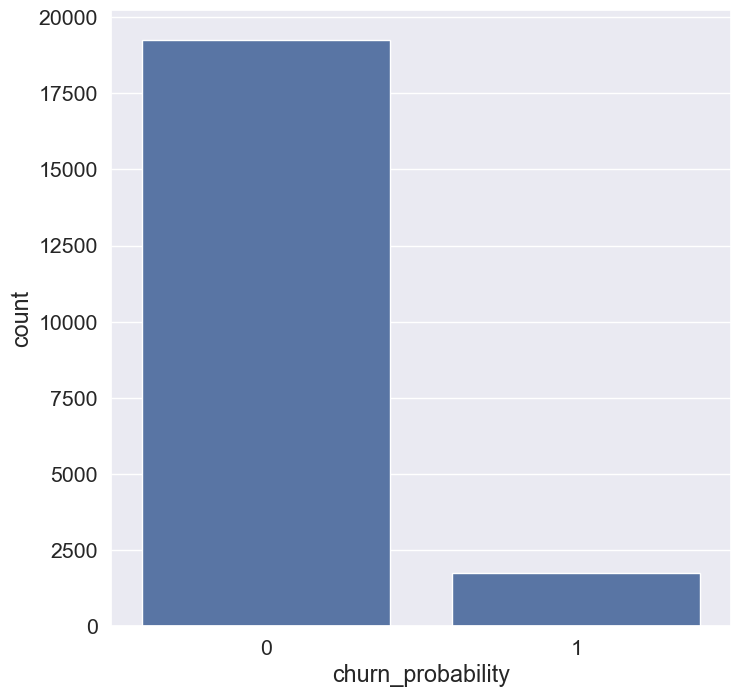

In [861]:
# Visualising Churn Ratio
plt.figure(figsize = (8,8))
sns.countplot(x=high_value_customer['churn_probability'])
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* Based on above plot it is clear that 91.74% of customers are non-churn category, while 8.26% of customer are churn category. This indicates imbalance in category.

### 2.6 Impute missing values using KNN Imputer

In [862]:
# Create a copy of high value customer dataframe
customer_data = high_value_customer.copy()
customer_data.reset_index(inplace=True)
customer_data.drop(['index'], axis=1, inplace=True)
customer_data.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,...,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability,total_amt_6,total_amt_7,total_avg_amt_6_7
0,240.708,128.191,101.565,21.28,4.83,6.13,56.99,38.11,9.63,53.64,...,1.0,1.0,647,0.0,0.00,0.00,0,1515.0,1473.0,1494.0
1,580.549,377.294,338.286,10.43,24.99,194.43,317.11,341.79,197.09,0.00,...,-1.0,1.0,602,0.0,0.00,0.00,0,808.0,400.0,604.0
2,1130.948,905.506,479.762,859.53,372.71,0.89,293.46,450.11,386.91,0.00,...,-1.0,-1.0,455,0.0,0.00,0.00,0,1420.0,990.0,1205.0
3,371.974,352.069,240.449,93.18,38.29,29.86,531.19,507.76,222.03,0.00,...,0.0,0.0,1219,0.0,0.00,0.00,0,463.0,519.0,491.0
4,390.489,350.985,421.300,8.58,11.48,12.68,133.16,158.73,182.83,0.00,...,1.0,1.0,573,700.4,185.71,173.72,0,1385.0,1180.0,1282.5


In [863]:
# List of missing columns
missing_ratio = round(customer_data.isna().sum()*100/customer_data.shape[0],2)
missing_val = missing_ratio[missing_ratio > 0]
missing_val.index

Index(['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6',
       'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7',
       'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8',
       'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8',
       'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8',
       'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8',
       'loc_og_t2c_mou_6', 'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8',
       'loc_og_mou_6', 'loc_og_mou_7', 'loc_og_mou_8', 'std_og_t2t_mou_6',
       'std_og_t2t_mou_7', 'std_og_t2t_mou_8', 'std_og_t2m_mou_6',
       'std_og_t2m_mou_7', 'std_og_t2m_mou_8', 'std_og_t2f_mou_6',
       'std_og_t2f_mou_7', 'std_og_t2f_mou_8', 'std_og_mou_6', 'std_og_mou_7',
       'std_og_mou_8', 'isd_og_mou_6', 'isd_og_mou_7', 'isd_og_mou_8',
       'spl_og_mou_6', 'spl_og_mou_7', 'spl_og_mou_8', 'og_others_6',
       'og_others_7', 'og_others_8', 'loc_ic_t2t_mou_6', 'loc_ic_t2t_mou_7',
       'lo

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* We cannot discard these missing values because doing so would result in the loss of valuable information. Instead, we will employ imputation techniques such as KNNImputer.

* KNNImputer is a technique used to impute missing values in a dataset based on the values of its nearest neighbors. It works by identifying the k nearest neighbors of each data point with missing values, then averaging or taking a weighted average of the available values from those neighbors to fill in the missing value. This approach leverages the similarity between data points to estimate the missing values more accurately.

In [864]:
# Crete imputer instance
imputer = KNNImputer(n_neighbors=5)

In [865]:
# Separate columns which need to be imputed from training dataset
impute_df = customer_data[list(missing_val.index)]
churn_df = customer_data.drop(list(missing_val.index), axis=1)
print(churn_df.shape)
print(impute_df.shape)
print(churn_df.shape[1] + impute_df.shape[1])
print(impute_df.isna().sum())

(20998, 68)
(20998, 81)
149
onnet_mou_6     396
onnet_mou_7     392
onnet_mou_8     821
offnet_mou_6    396
offnet_mou_7    392
               ... 
isd_ic_mou_7    392
isd_ic_mou_8    821
ic_others_6     396
ic_others_7     392
ic_others_8     821
Length: 81, dtype: int64


In [866]:
# Separate columns which need to be imputed from test dataset
impute_df_unseen = unseen_data[list(missing_val.index)]
churn_df_unseen = unseen_data.drop(list(missing_val.index), axis=1)
print(churn_df_unseen.shape)
print(impute_df_unseen.shape)
print(impute_df_unseen.shape[1] + churn_df_unseen.shape[1])
print(impute_df_unseen.isna().sum())

(30000, 68)
(30000, 81)
149
onnet_mou_6     1169
onnet_mou_7     1172
onnet_mou_8     1675
offnet_mou_6    1169
offnet_mou_7    1172
                ... 
isd_ic_mou_7    1172
isd_ic_mou_8    1675
ic_others_6     1169
ic_others_7     1172
ic_others_8     1675
Length: 81, dtype: int64


In [867]:
%%time
# impute using KNN imputer Instance for training dataset
imputer_transform = imputer.fit_transform(impute_df)

CPU times: user 7.94 s, sys: 2.12 s, total: 10.1 s
Wall time: 9.39 s


In [868]:
%%time
# impute using KNN imputer Instance for test dataset
imputer_transform_unseen = imputer.fit_transform(impute_df_unseen)

CPU times: user 34.1 s, sys: 12.5 s, total: 46.5 s
Wall time: 44.6 s


In [869]:
# Convert training imputer transorm to df post imputation
imp_df = pd.DataFrame(imputer_transform, columns=list(missing_val.index))
imp_df.head()

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,std_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8
0,21.28,4.83,6.13,56.99,38.11,9.63,53.64,0.0,0.0,15.73,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
1,10.43,24.99,194.43,317.11,341.79,197.09,0.00,0.0,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
2,859.53,372.71,0.89,293.46,450.11,386.91,0.00,0.0,0.0,0.00,...,0.00,0.13,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.4
3,93.18,38.29,29.86,531.19,507.76,222.03,0.00,0.0,0.0,0.00,...,21.93,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
4,8.58,11.48,12.68,133.16,158.73,182.83,0.00,0.0,0.0,0.00,...,0.40,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0


In [870]:
# Convert test imputer transorm to df post imputation
imp_df_unseen = pd.DataFrame(imputer_transform_unseen, columns=list(missing_val.index))
imp_df.head()

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,std_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8
0,21.28,4.83,6.13,56.99,38.11,9.63,53.64,0.0,0.0,15.73,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
1,10.43,24.99,194.43,317.11,341.79,197.09,0.00,0.0,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
2,859.53,372.71,0.89,293.46,450.11,386.91,0.00,0.0,0.0,0.00,...,0.00,0.13,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.4
3,93.18,38.29,29.86,531.19,507.76,222.03,0.00,0.0,0.0,0.00,...,21.93,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
4,8.58,11.48,12.68,133.16,158.73,182.83,0.00,0.0,0.0,0.00,...,0.40,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0


In [871]:
imp_df.isna().sum()

onnet_mou_6     0
onnet_mou_7     0
onnet_mou_8     0
offnet_mou_6    0
offnet_mou_7    0
               ..
isd_ic_mou_7    0
isd_ic_mou_8    0
ic_others_6     0
ic_others_7     0
ic_others_8     0
Length: 81, dtype: int64

In [872]:
imp_df_unseen.isna().sum()

onnet_mou_6     0
onnet_mou_7     0
onnet_mou_8     0
offnet_mou_6    0
offnet_mou_7    0
               ..
isd_ic_mou_7    0
isd_ic_mou_8    0
ic_others_6     0
ic_others_7     0
ic_others_8     0
Length: 81, dtype: int64

In [873]:
# Merge the two dataframe of training dataset post imputation to create the final dataset
final_df = pd.concat([imp_df, churn_df], join='inner', axis=1)
final_df.shape

(20998, 149)

In [874]:
# Merge the two dataframe of test dataset post imputation to create the final dataset
final_df_unseen = pd.concat([imp_df_unseen, churn_df_unseen], join='inner', axis=1)
final_df_unseen.shape

(30000, 149)

## 3. Common Methods

In [875]:
def plot_bar_graph(title, month, y_list, data):
    plt.figure(figsize=(15, 10))
    
    for i, m in enumerate(month):
        plt.subplot(2, 3, i+1)
        plt.title(f'{title} for {m}')
        sns.barplot(x='churn_probability', y=y_list[i], data=data)
    
    plt.tight_layout()
    plt.show()

In [876]:
def outlier_handling(dataframe):
    transformed_values = []
    for value in dataframe:
        if value <= 0:
            transformed_values.append(float(0))
        elif float(value) == float(1.0):
            transformed_values.append(float(1.5))
        else:
            transformed_values.append(float(np.log1p(value)))

    return transformed_values

In [877]:
def calculate_classification_metrics(y_true, y_pred):
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion Matrix')
    print()
    print(cm)
    
    # True Positives, False Positives, True Negatives, False Negatives
    TP = cm[1, 1]
    FP = cm[0, 1]
    TN = cm[0, 0]
    FN = cm[1, 0]

    # Accuracy Score
    accuracy = round((TP + TN) / (TP + FP + TN + FN), 4)

    # Sensitivity (Recall or True Positive Rate)
    sensitivity = round(TP / (TP + FN), 4)

    # Specificity
    specificity = round(TN / (TN + FP), 4)

    # Precision
    precision = round(TP / (TP + FP), 4)

    # False Positive Rate
    false_positive_rate = round(FP / (FP + TN), 4)

    # True Positive Rate
    true_positive_rate = sensitivity

    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'False Positive Rate', 'True Positive Rate'],
        'Value': [accuracy, sensitivity, specificity, precision, false_positive_rate, true_positive_rate]
    })

    return metrics_df

In [878]:
def draw_roc(actual, probs):
    fpr, tpr, thresholds = roc_curve(actual, probs,drop_intermediate = False)
    auc_score = roc_auc_score( actual, probs )
    plt.figure(figsize=(6, 6))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('ROC AUC Curve')
    plt.legend(loc="lower right")
    plt.show()

    return fpr, tpr, thresholds

## 4. Exploratory Data Analysis (EDA)

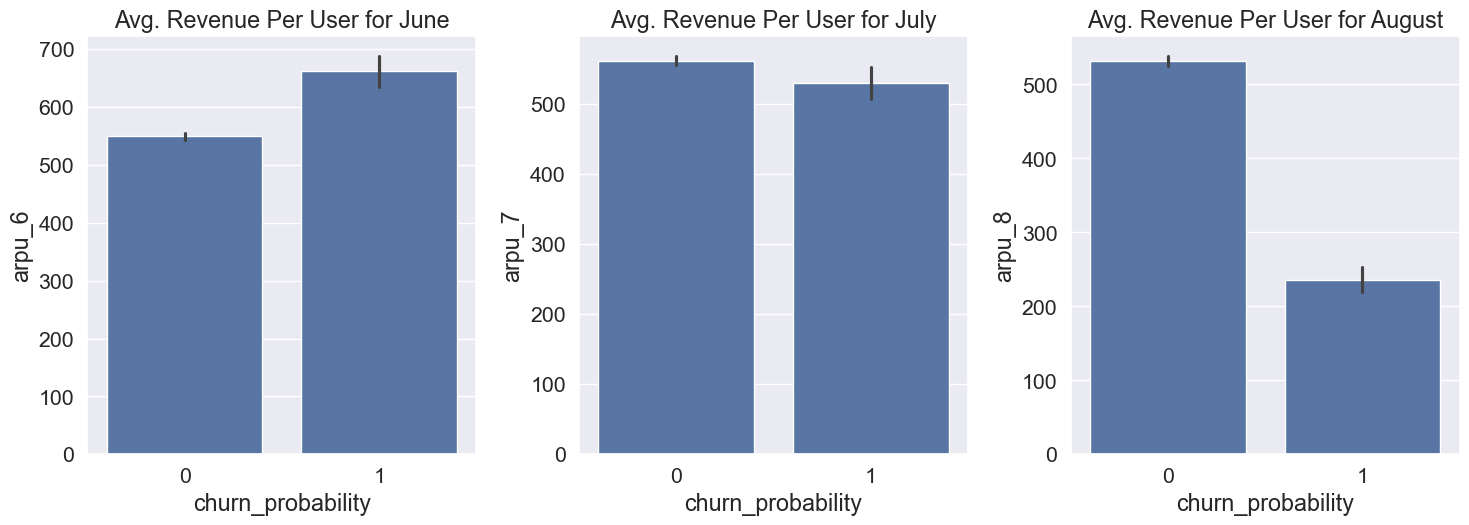

In [879]:
# Visualising Average Revenue per user
arpu_cols = ['arpu_6', 'arpu_7', 'arpu_8']
plot_bar_graph('Avg. Revenue Per User', ['June', 'July', 'August'], arpu_cols, final_df)

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* The decline in the Average Revenue Per User (ARPU) in month of August suggests churn.

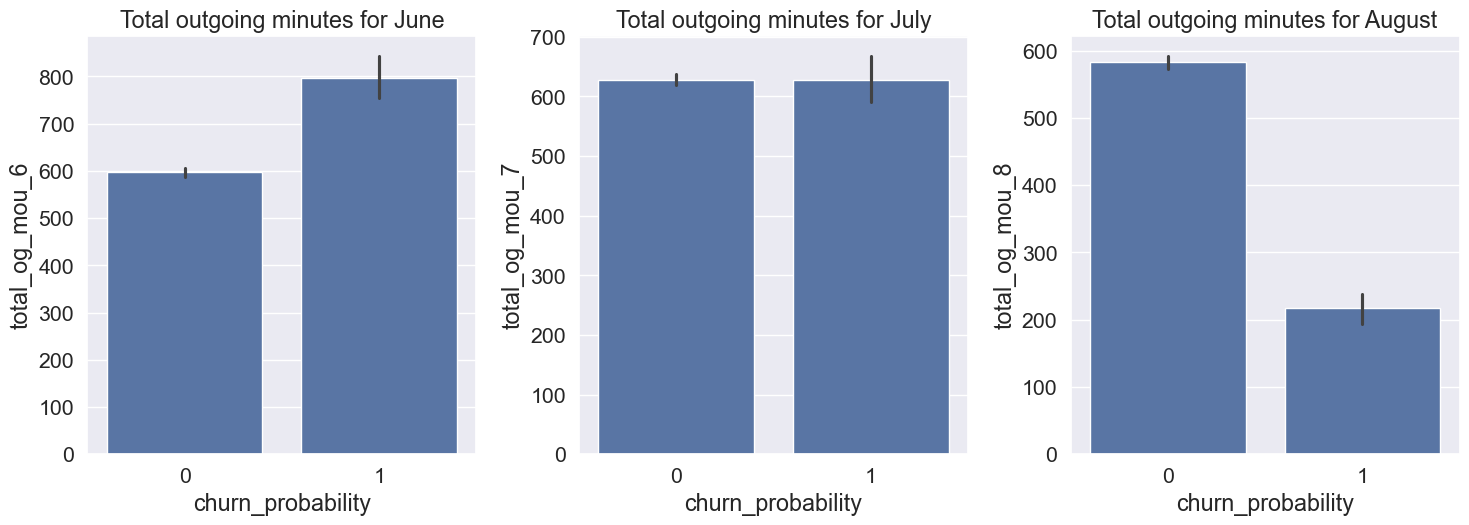

In [880]:
# Visualising Outgoing minutes of usage
total_og_mou_cols = ['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']
plot_bar_graph('Total outgoing minutes', ['June', 'July', 'August'], total_og_mou_cols, final_df)

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* The decline in the Total outgoing minutes in month of August suggests churn.

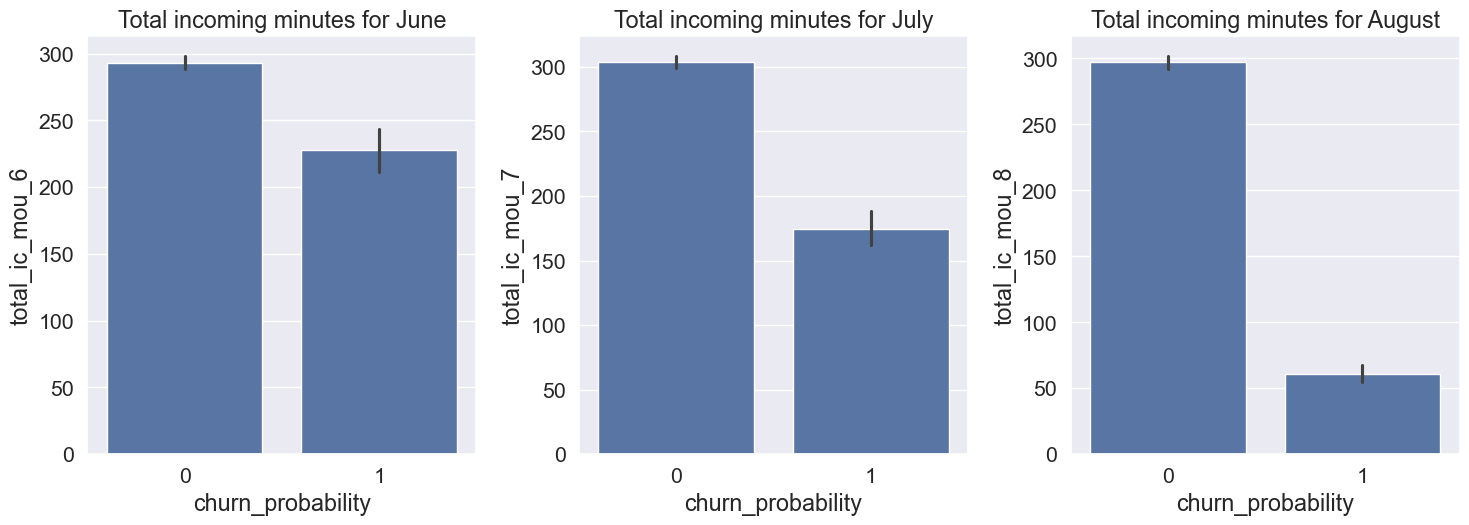

In [881]:
# Visualising incoming minutes of usage
total_ic_mou_cols = ['total_ic_mou_6', 'total_ic_mou_7', 'total_ic_mou_8']
plot_bar_graph('Total incoming minutes', ['June', 'July', 'August'], total_ic_mou_cols, final_df)

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* The decline in the Total incoming minutes in month of August suggests churn.

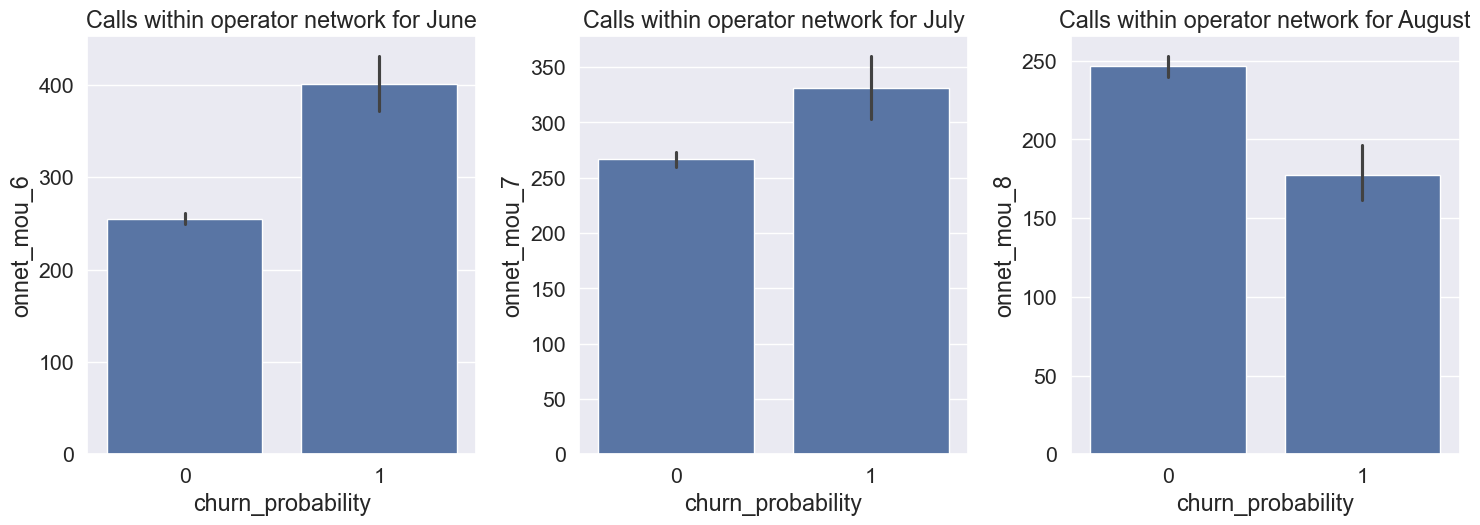

In [882]:
# Visualizing all types of calls within the operator's network.
onnet_mou_cols = ['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8']
plot_bar_graph('Calls within operator network', ['June', 'July', 'August'], onnet_mou_cols, final_df)

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* The decline in the Calls outside operator network in month of August suggests churn.

In [883]:
# Analysing different metrics by extracting them into columns of similar type
amount_data = final_df.loc[:, final_df.columns.str.contains('amt')]
data2g = final_df.loc[:, final_df.columns.str.contains('2g')]
data3g = final_df.loc[:, final_df.columns.str.contains('3g')]
ic_mou_data = final_df.loc[:, final_df.columns.str.contains('ic') & final_df.columns.str.contains('mou')]
net_mou_data = final_df.loc[:, final_df.columns.str.contains('net_mou')]
og_mou_data = final_df.loc[:, final_df.columns.str.contains('og') & final_df.columns.str.contains('mou')]
rech_data = final_df.loc[:, final_df.columns.str.contains('rech')]
total_data = final_df.loc[:, final_df.columns.str.contains('tot')]

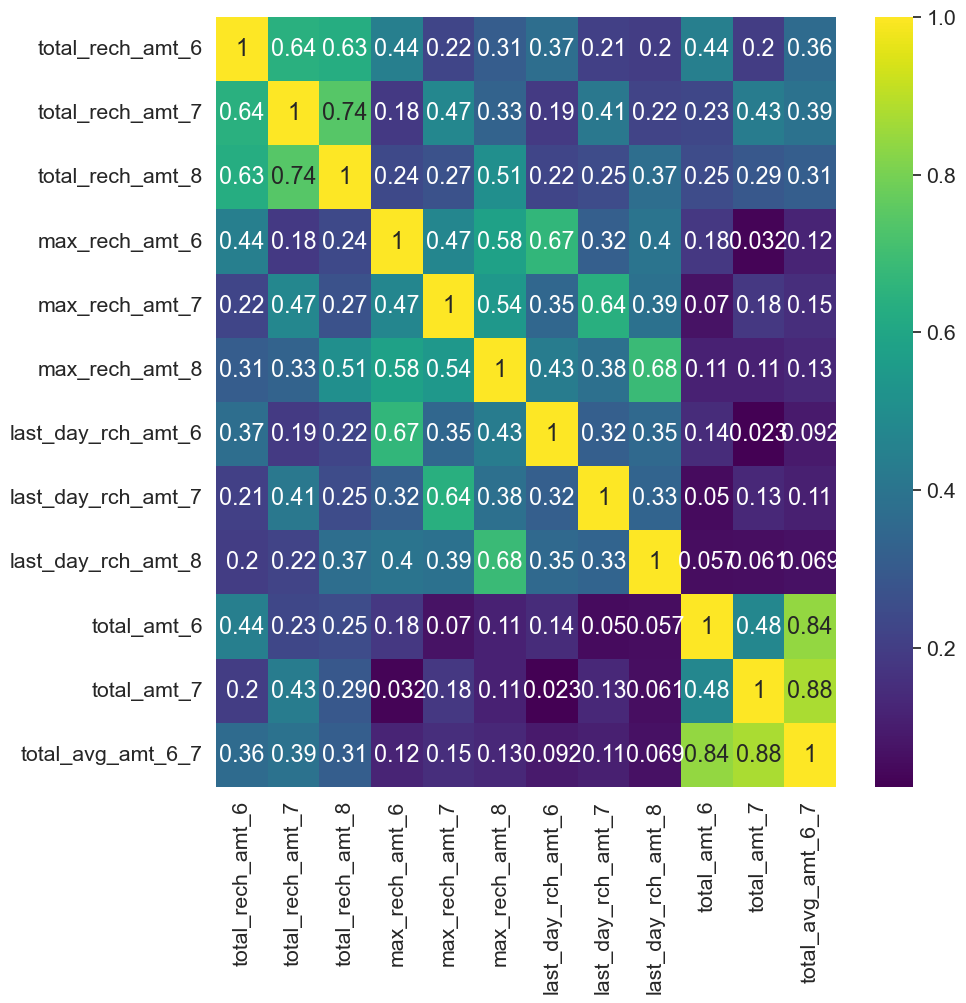

In [884]:
# Amount data
plt.figure(figsize=(10,10))
sns.heatmap(amount_data.corr(), annot=True, cmap='viridis')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* A substantial correlation of 74% exists between the total recharge amount in month 7 and month 8.
* Similarly, a notable correlation of 68% is observed between the maximum recharge amount in month 8 and the last day's recharge amount in the same month.
* This suggests that customers who are unlikely to churn tend to recharge higher amounts in month 8.

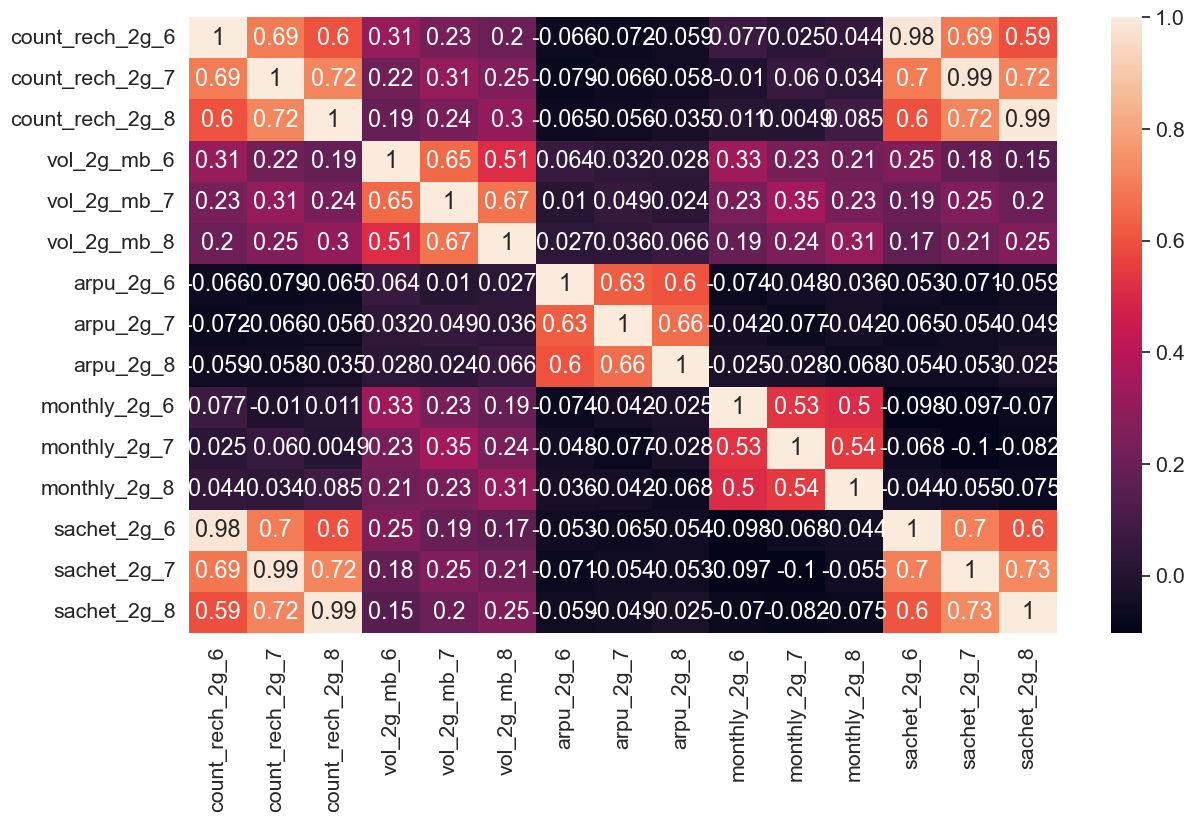

In [885]:
# data2g
plt.figure(figsize=(14,8))
sns.heatmap(data2g.corr(), annot=True)
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* There is a strong correlation between recharge quantities in months 7 and 8.

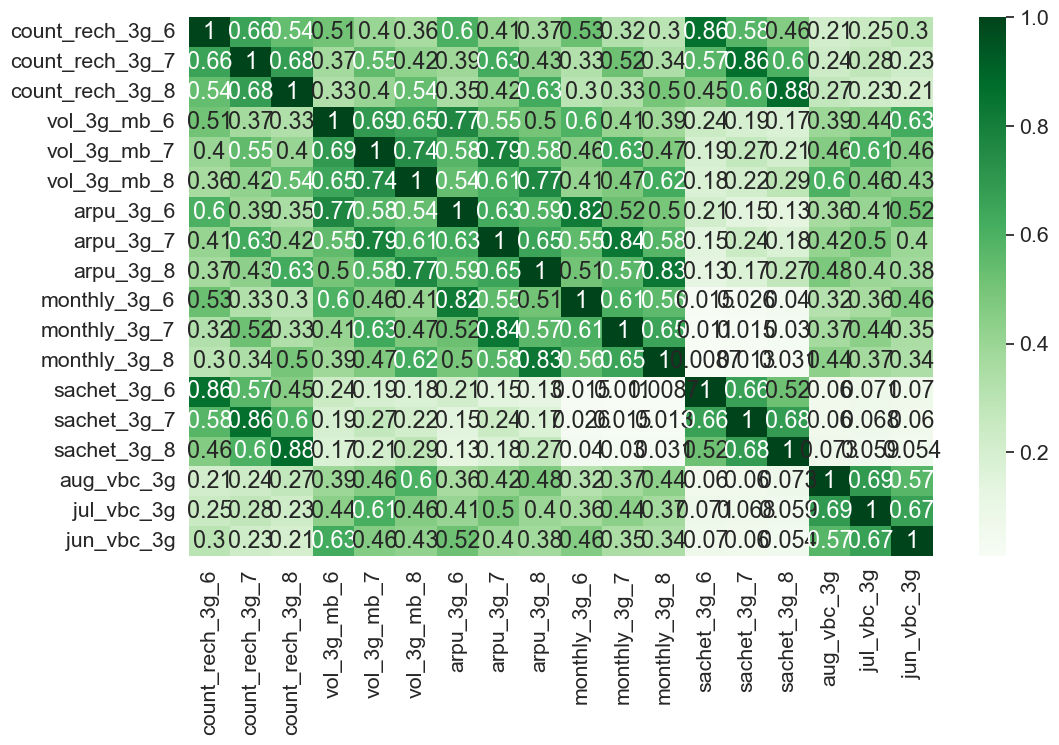

In [886]:
#data3g
plt.figure(figsize=(12,7))
sns.heatmap(data3g.corr(),annot=True, cmap='Greens')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* There is a strong correlation between recharge quantities in months 7 and 8.

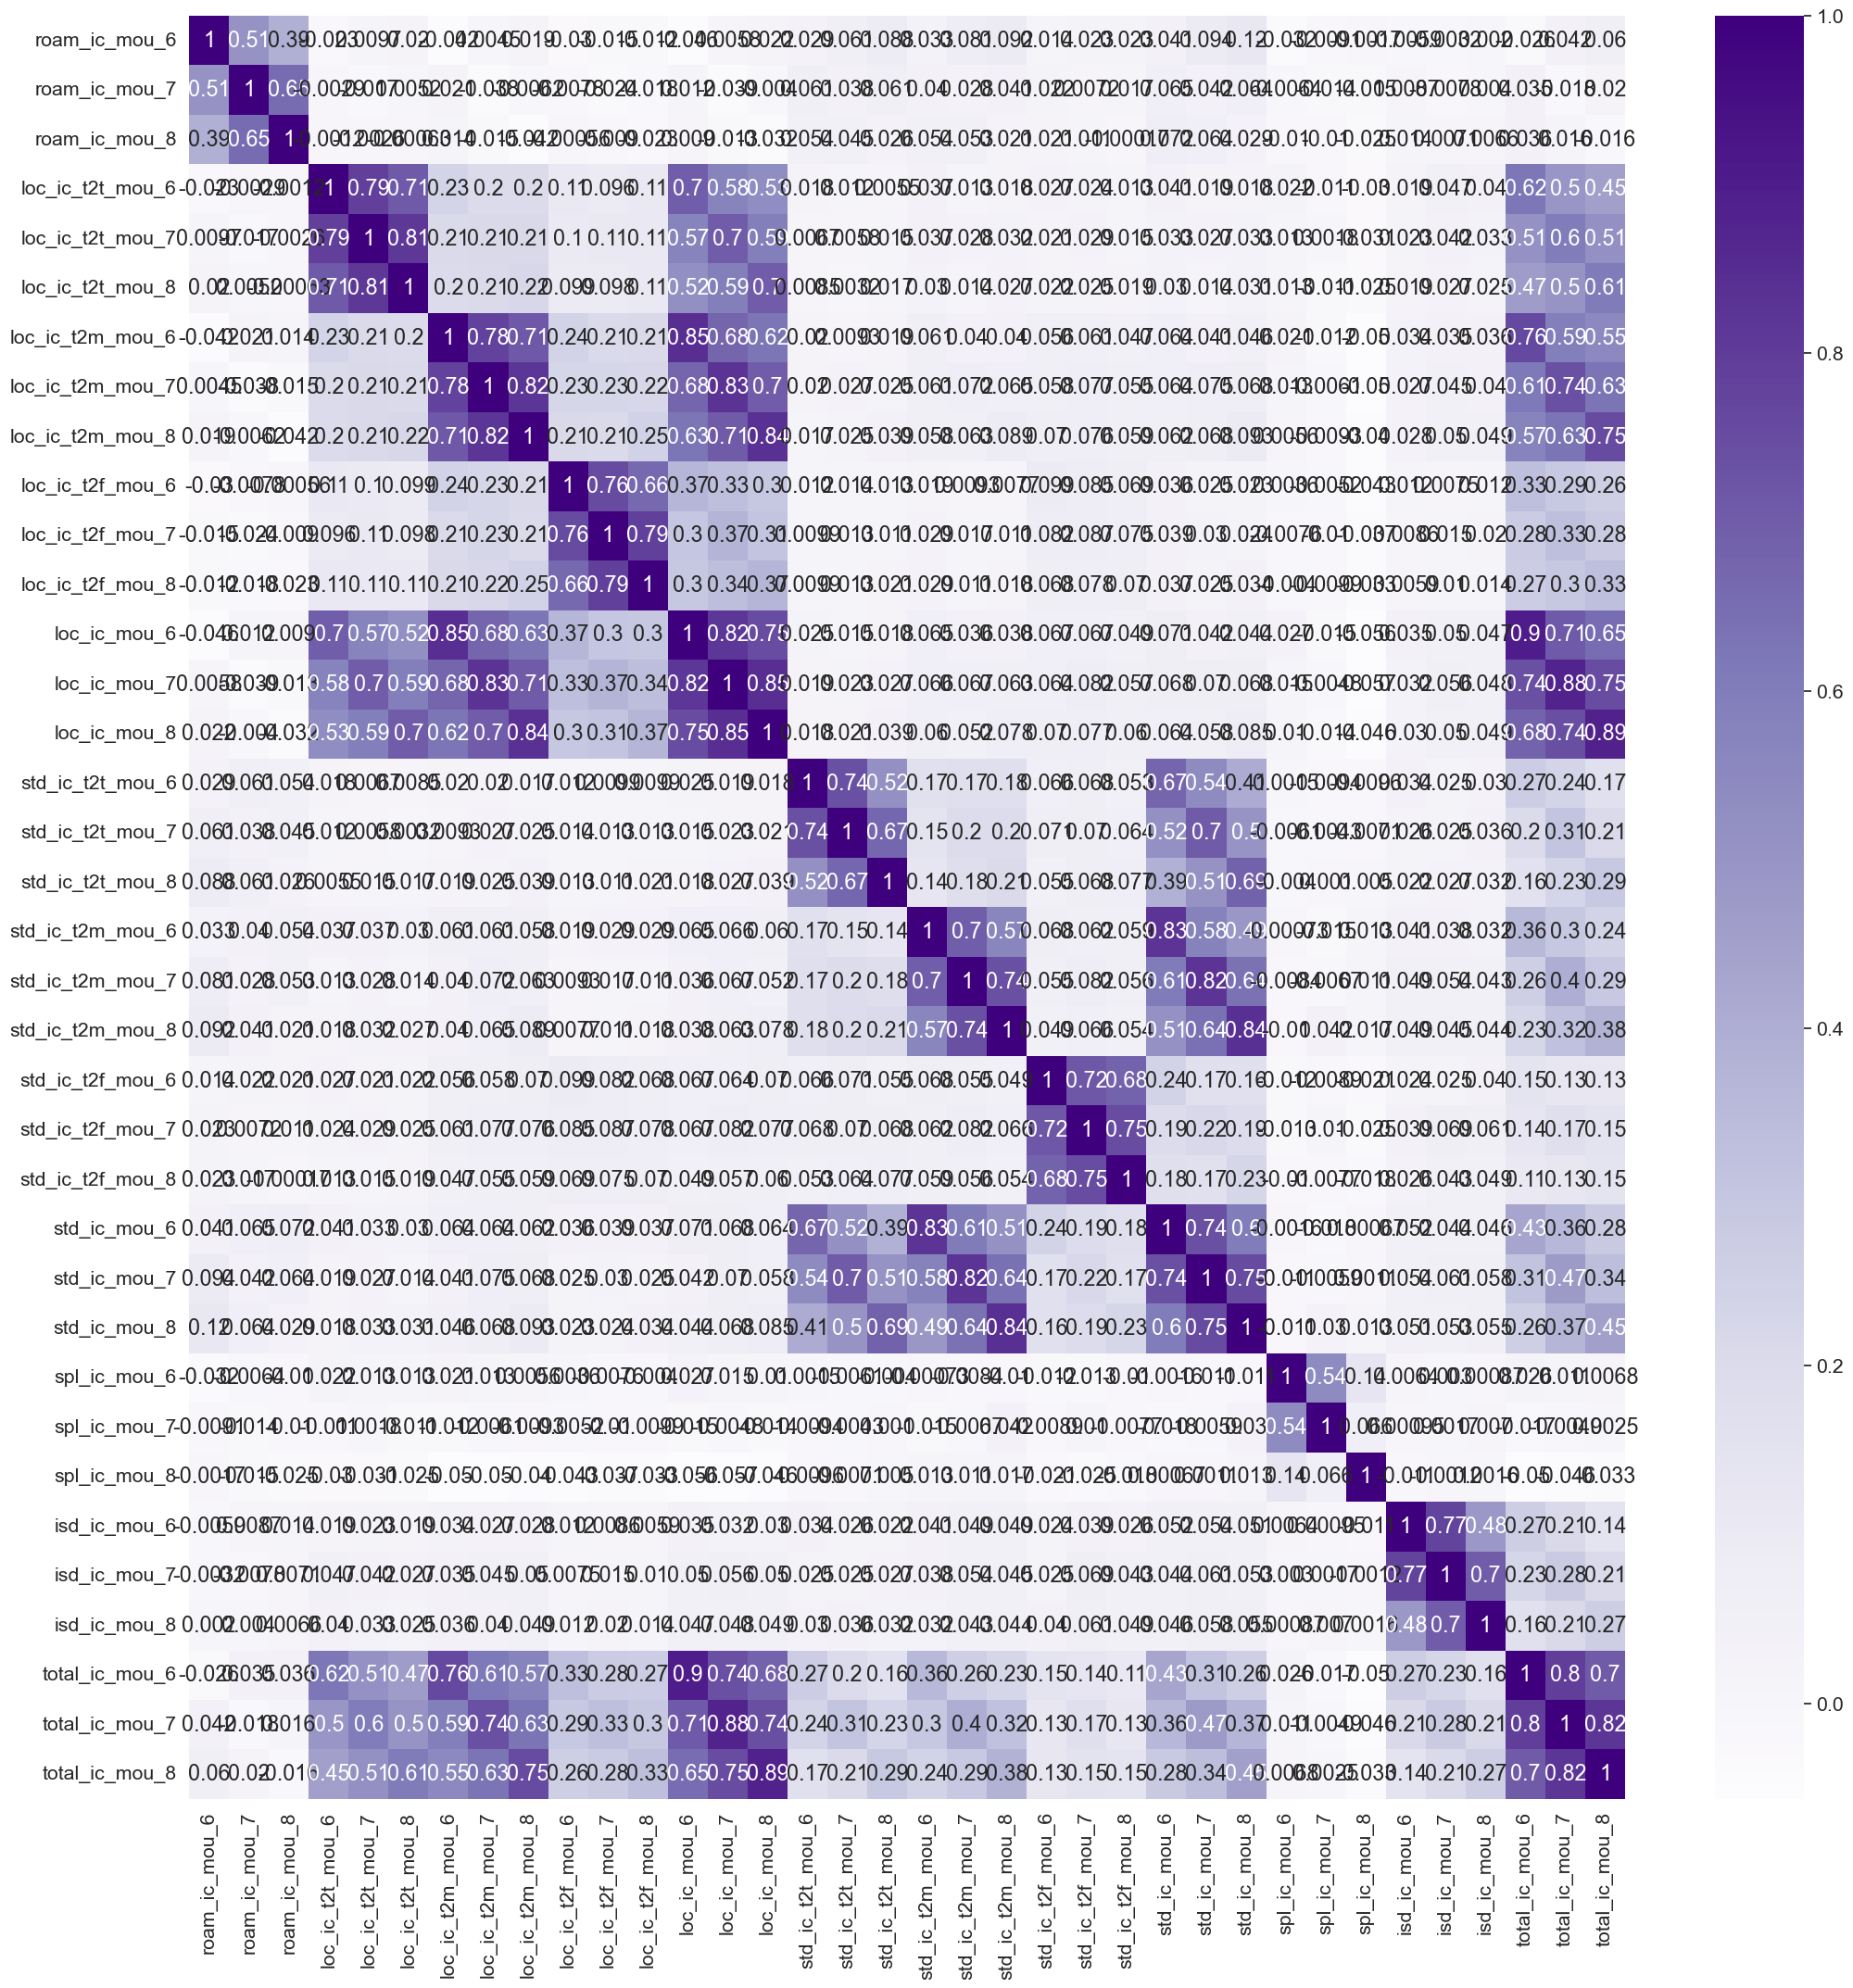

In [887]:
#ic_mou_data
plt.figure(figsize=(25, 25))
sns.heatmap(ic_mou_data.corr(), annot=True, cmap='Purples')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

The following variables or features exhibit a remarkably high correlation:

* total_ic_mou_6 and loc_ic_mou_6
* total_ic_mou_7 and loc_ic_mou_7
* total_ic_mou_8 and loc_ic_mou_8
* std_ic_mou_6 and std_ic_t2f_mou_6
* std_ic_mou_7 and std_ic_t2f_mou_7
* std_ic_mou_8 and std_ic_t2f_mou_8

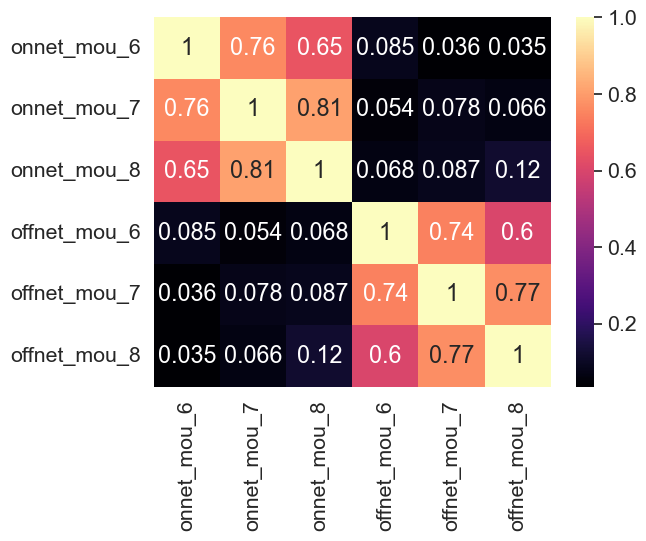

In [888]:
#net_mou_data
sns.heatmap(net_mou_data.corr(), annot=True, cmap='magma')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* There is no correlation between the usage minutes for on-net and off-net calls.
* However, a significant correlation is observed between the on-net and off-net usage minutes in both months 7 and 8.

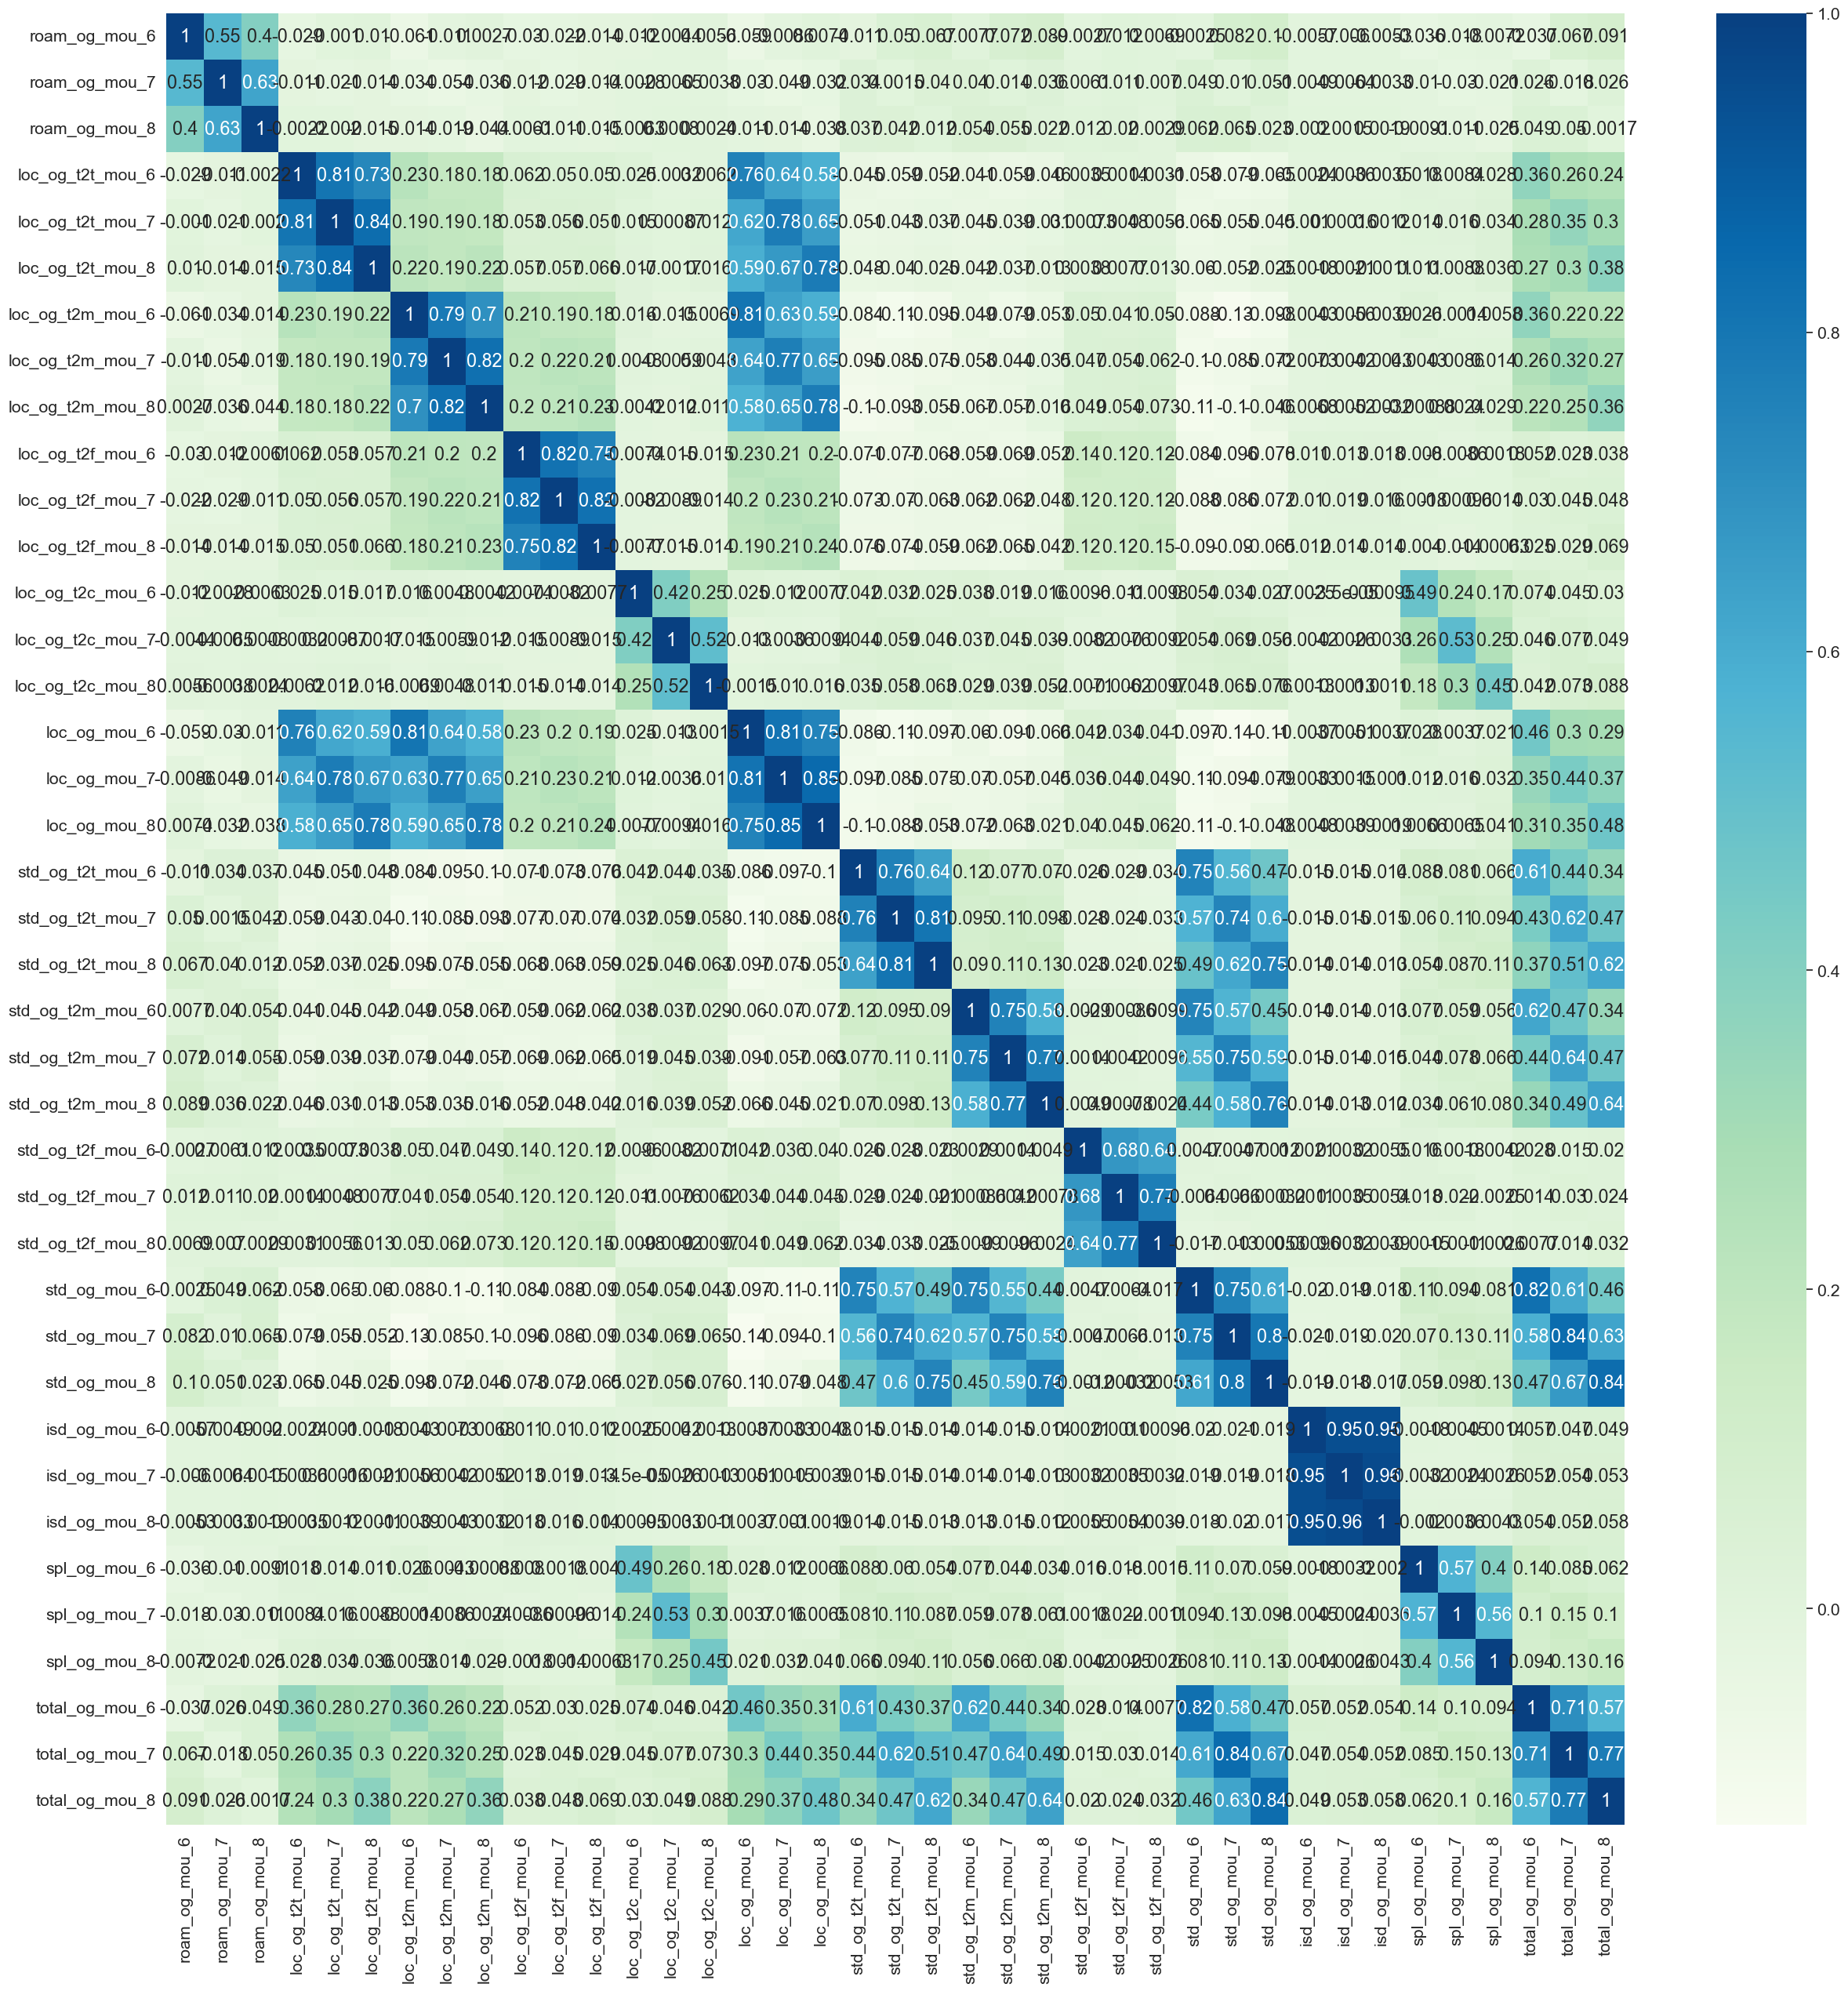

In [889]:
#og_mou_data
plt.figure(figsize=(30,30))
sns.heatmap(og_mou_data.corr(), annot=True, cmap='GnBu')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

There exists a very high correlation between the following variables/features:
* isd_og_mou_7 and isd_og_mou_6
* isd_og_mou_8 and isd_og_mou_6
* isd_og_mou_8 and isd_og_mou_7
* total_og_mou_6 and std_og_mou_6
* total_og_mou_7 and std_og_mou_7
* total_og_mou_8 and std_og_mou_8

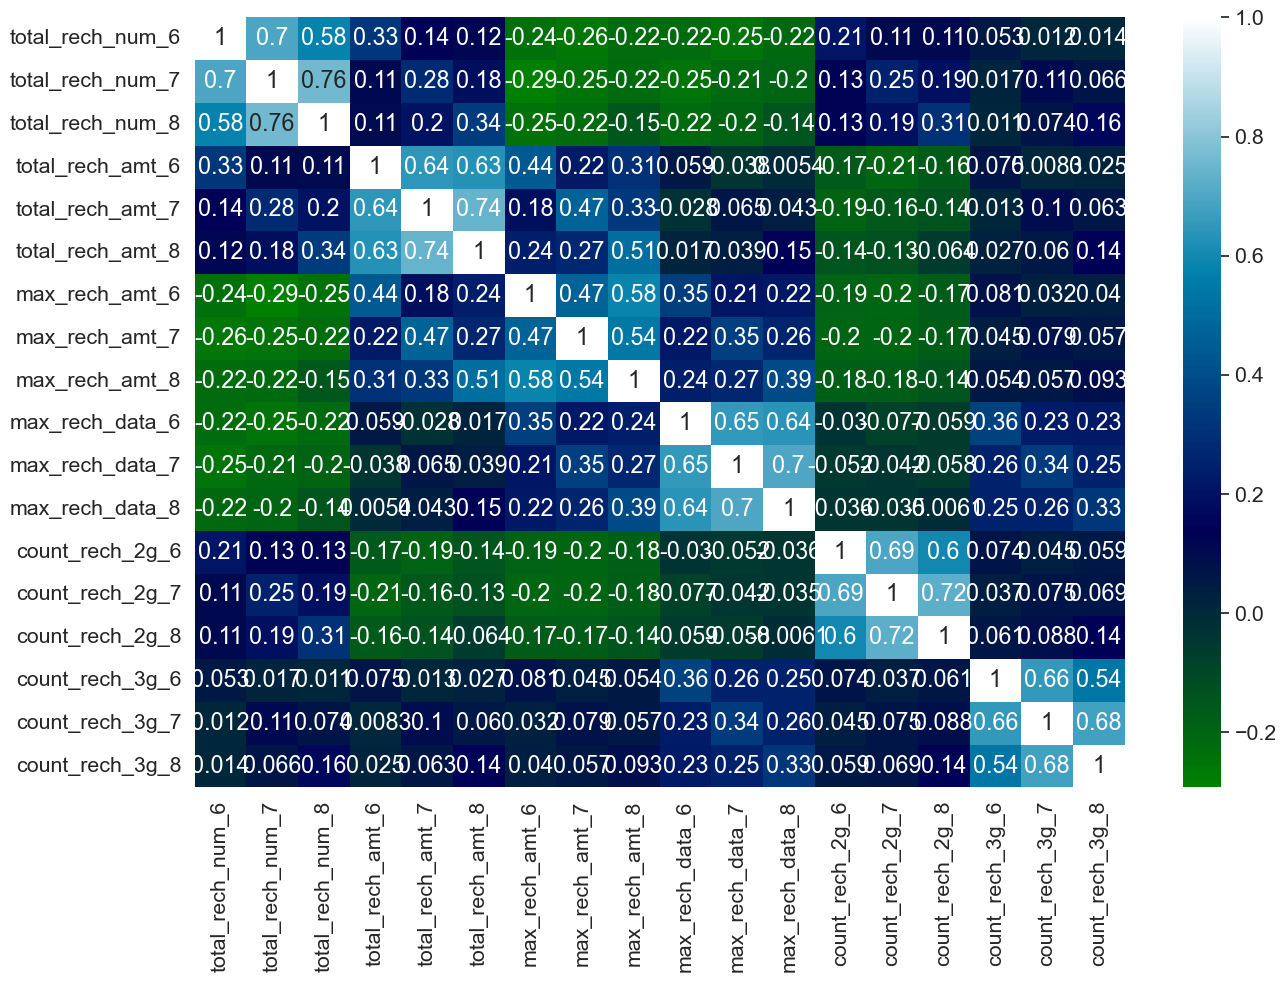

In [890]:
#rech_data
plt.figure(figsize=(15,10))
sns.heatmap(rech_data.corr(), annot=True, cmap='ocean')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* There is a notable correlation between the average recharge amount and the recharge amount for both months 6 and 7.
* A significant correlation of 76% exists between the total recharge for month 7 and the recharge for month 8.
 * Any factor correlated with month 8 is likely correlated with churn prediction.

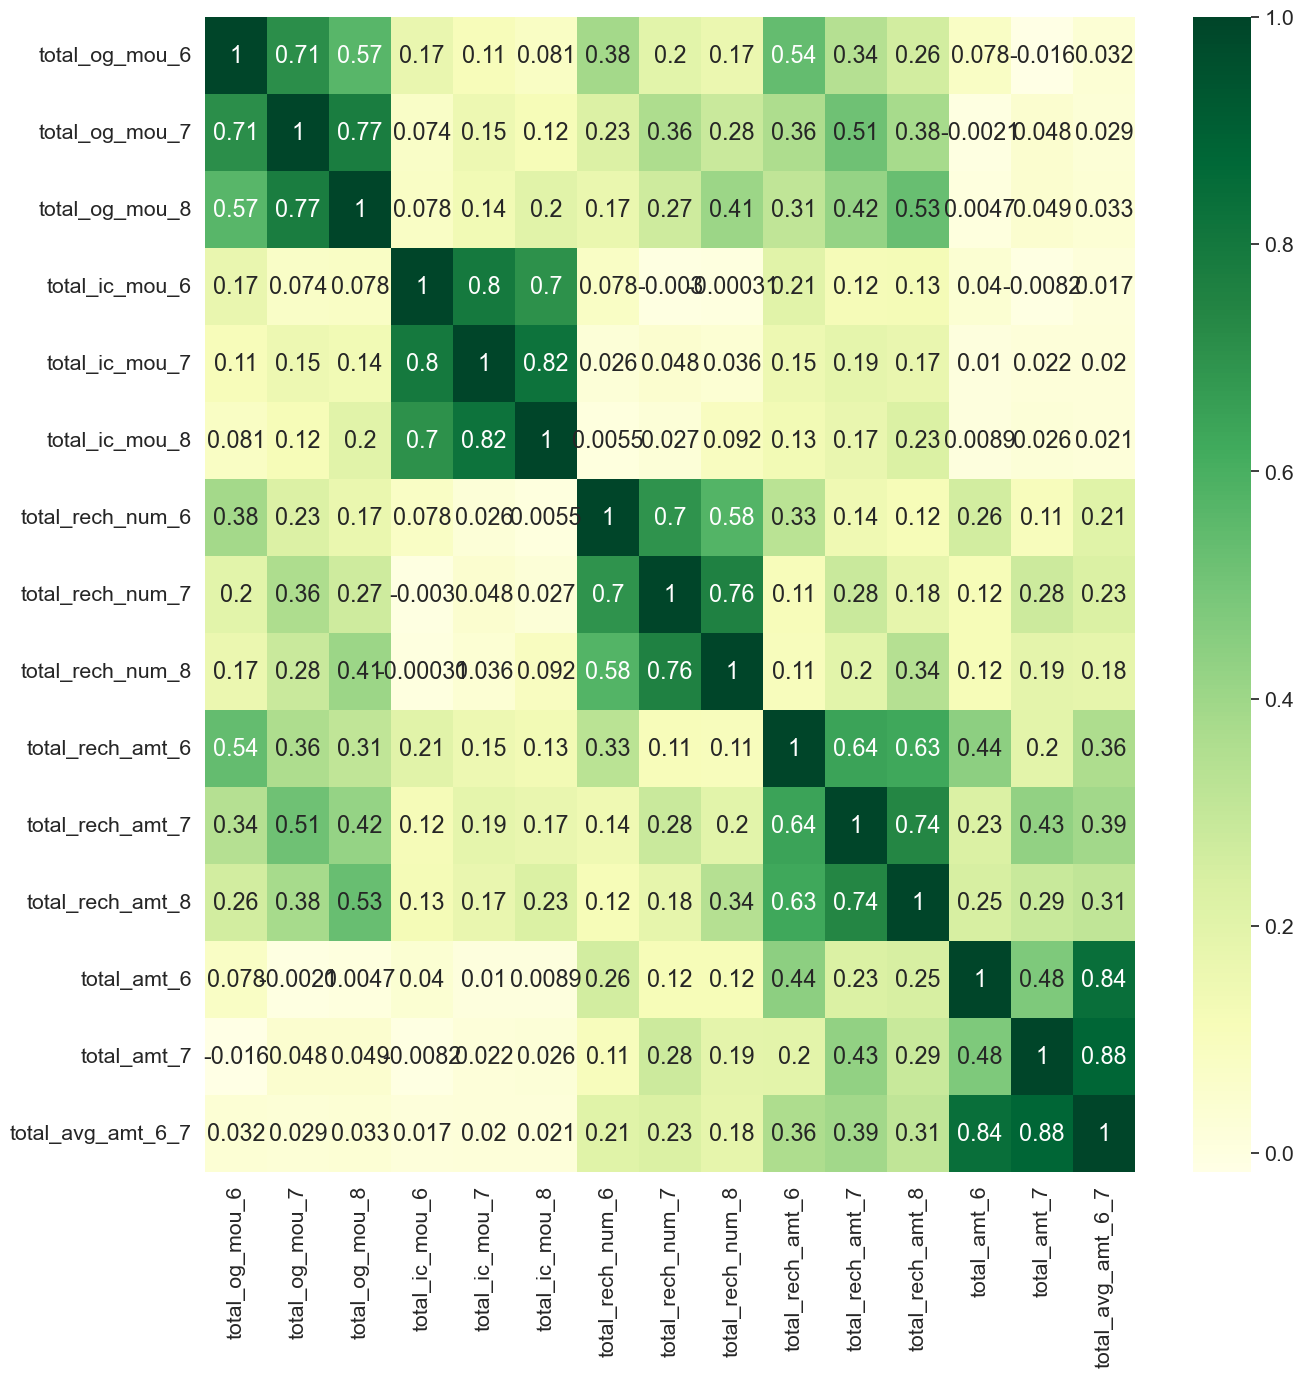

In [891]:
#total_data
plt.figure(figsize=(15,15))
sns.heatmap(total_data.corr(), annot=True, cmap='YlGn')
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* There exists a remarkably high correlation between the incoming (82%) and outgoing minutes (77%) of usage in months 7 and 8.
* Heavy usage suggests that customers are less likely to churn.

## 5. Dummy Variable Creation 

In [892]:
final_df.shape

(20998, 149)

In [893]:
# Creating dummies for training categorical columns
dummy_data = pd.get_dummies(final_df[['night_pck_user_8', 'fb_user_8', 'fb_user_7', 'fb_user_6', 'night_pck_user_7', 'night_pck_user_6']], drop_first=True, dtype='int')
dummy_data

,night_pck_user_8_0.0,night_pck_user_8_1.0,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
0,1,0,0,1,0,1,0,1,1,0,1,0
1,1,0,0,1,0,0,0,1,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,1,0,1,0,1,0,1,0
4,1,0,0,1,0,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
20993,0,0,0,0,0,0,0,1,0,0,1,0
20994,1,0,0,1,0,1,0,1,1,0,0,1
20995,0,0,0,0,0,1,0,1,1,0,1,0
20996,1,0,0,1,0,1,0,0,1,0,0,0


In [894]:
# Creating dummies for test categorical columns
dummy_data_unseen = pd.get_dummies(final_df_unseen[['night_pck_user_8', 'fb_user_8', 'fb_user_7', 'fb_user_6', 'night_pck_user_7', 'night_pck_user_6']], drop_first=True, dtype='int')
dummy_data_unseen

,night_pck_user_8_0.0,night_pck_user_8_1.0,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0,0,0,0,0,0,0,1,0,0,1,0
29996,0,0,0,0,1,0,0,0,1,0,0,0
29997,0,0,0,0,0,0,0,0,0,0,0,0
29998,0,0,0,0,0,0,0,0,0,0,0,0


In [895]:
final_df = pd.concat([final_df,dummy_data],axis=1)
final_df.shape

(20998, 161)

In [896]:
final_df_unseen = pd.concat([final_df_unseen,dummy_data_unseen],axis=1)
final_df_unseen.shape

(30000, 161)

In [897]:
# drop the category cols training set
final_df.drop(['night_pck_user_8', 'fb_user_8', 'fb_user_7', 'fb_user_6', 'night_pck_user_7', 'night_pck_user_6'], axis=1, inplace=True)
final_df.shape

(20998, 155)

In [898]:
# drop the category cols for testing set
final_df_unseen.drop(['night_pck_user_8', 'fb_user_8', 'fb_user_7', 'fb_user_6', 'night_pck_user_7', 'night_pck_user_6'], axis=1, inplace=True)
final_df_unseen.shape

(30000, 155)

## 6. Outlier Treatment

In [899]:
# Checking outliers at 25%, 50%, 75%, 90%, 95% and 99%
final_df.describe(percentiles=[.25, .50, .75, .90, .95, .99])

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
count,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,...,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000
mean,267.178107,272.109430,240.685531,382.267956,383.250630,344.876032,16.405591,13.039014,12.474249,27.934119,...,0.055624,0.476617,0.043433,0.523955,0.039670,0.516811,0.554339,0.013049,0.543290,0.013192
std,466.100504,486.527458,465.230834,480.519770,490.938657,476.342965,77.640328,77.874472,72.898547,120.392036,...,0.229200,0.499465,0.203834,0.499438,0.195188,0.499729,0.497050,0.113487,0.498134,0.114098
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.440000,17.940000,13.815000,79.540000,75.790000,58.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,90.235000,87.830000,72.685000,234.680000,228.825000,198.600000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
75%,292.127500,290.620000,245.405000,495.280000,498.790000,444.155500,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
90%,766.325000,788.211000,672.592000,912.390000,922.828000,841.962000,28.202000,14.731000,15.916000,52.940000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
95%,1147.706000,1194.174500,1086.979500,1265.446000,1274.301500,1172.576500,86.367500,56.947500,56.103500,154.087500,...,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
99%,2164.456000,2239.353000,2153.499100,2338.036700,2394.084300,2178.008900,335.603500,283.862000,276.136000,546.030900,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [900]:
numerical_cols = list(final_df.select_dtypes(exclude='category'))
print(len(numerical_cols))
print(numerical_cols)

154
['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8', 'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8', 'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8', 'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8', 'loc_og_t2c_mou_6', 'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8', 'loc_og_mou_6', 'loc_og_mou_7', 'loc_og_mou_8', 'std_og_t2t_mou_6', 'std_og_t2t_mou_7', 'std_og_t2t_mou_8', 'std_og_t2m_mou_6', 'std_og_t2m_mou_7', 'std_og_t2m_mou_8', 'std_og_t2f_mou_6', 'std_og_t2f_mou_7', 'std_og_t2f_mou_8', 'std_og_mou_6', 'std_og_mou_7', 'std_og_mou_8', 'isd_og_mou_6', 'isd_og_mou_7', 'isd_og_mou_8', 'spl_og_mou_6', 'spl_og_mou_7', 'spl_og_mou_8', 'og_others_6', 'og_others_7', 'og_others_8', 'loc_ic_t2t_mou_6', 'loc_ic_t2t_mou_7', 'loc_ic_t2t_mou_8', 'loc_ic_t2m_mou_6', 'loc_ic_t2m_mou_7', 'loc_ic_t2m_mou_8', 'loc_ic_t2f_mou_6', 'lo

In [901]:
# Handle outliers of numerical columns in training set
final_df[numerical_cols] = final_df[numerical_cols].apply(outlier_handling)

In [902]:
# Handle outliers of numerical columns in test set
final_df_unseen[numerical_cols] = final_df_unseen[numerical_cols].apply(outlier_handling)

In [903]:
# Inspecting the numerical columns again in the train set
final_df.describe(percentiles=[.25, .50, .75, .90 , .95, .99])

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
count,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,...,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000,20998.000000
mean,4.211145,4.187538,3.998147,5.094089,5.069495,4.867763,0.714727,0.566272,0.595661,0.835724,...,0.083437,0.714925,0.065149,0.785932,0.059506,0.775217,0.831508,0.019573,0.814935,0.019788
std,2.016302,2.044539,2.066760,1.674879,1.700994,1.803707,1.516127,1.366641,1.367898,1.728675,...,0.343800,0.749197,0.305751,0.749157,0.292783,0.749594,0.745576,0.170230,0.747201,0.171147
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.017494,2.941276,2.695640,4.388754,4.341074,4.077537,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.513439,4.486724,4.299799,5.462475,5.437318,5.296315,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.500000,0.000000,1.500000,1.500000,0.000000,1.500000,0.000000
75%,5.680608,5.675452,5.506977,6.207140,6.214188,6.098424,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.500000,0.000000,1.500000,0.000000,1.500000,1.500000,0.000000,1.500000,0.000000
90%,6.642910,6.671034,6.512625,6.817163,6.828526,6.736922,3.374237,2.755631,2.828260,3.987872,...,0.000000,1.500000,0.000000,1.500000,0.000000,1.500000,1.500000,0.000000,1.500000,0.000000
95%,7.046391,7.086047,6.992078,7.143970,7.150938,7.067811,4.470123,4.059537,4.044865,5.043989,...,1.500000,1.500000,0.000000,1.500000,0.000000,1.500000,1.500000,0.000000,1.500000,0.000000
99%,7.680386,7.714389,7.675314,7.757494,7.781174,7.686625,5.818906,5.652004,5.624508,6.304505,...,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000,1.500000


In [904]:
# Inspecting the numerical columns again in the test set
final_df_unseen.describe(percentiles=[.25, .50, .75, .90 , .95, .99])

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.00000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,3.436204,3.390065,3.409301,4.351470,4.310611,4.317048,0.566177,0.430250,0.440297,0.663376,...,0.04280,0.353300,0.03585,0.349450,0.034150,0.345100,0.377350,0.007950,0.369900,0.009350
std,1.899664,1.925861,1.922903,1.623089,1.647955,1.652369,1.279054,1.113232,1.135626,1.437236,...,0.24974,0.636508,0.22911,0.634092,0.223742,0.631323,0.650881,0.108914,0.646559,0.118059
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.166937,2.083185,2.102608,3.601550,3.522781,3.551914,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.624608,3.548467,3.577389,4.599152,4.540738,4.570682,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.830272,4.807621,4.842572,5.427447,5.406499,5.406869,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,1.500000,0.000000,0.000000,0.000000
90%,5.824237,5.832955,5.844538,6.136177,6.159237,6.168843,2.538605,2.136045,2.193581,3.174380,...,0.00000,1.500000,0.00000,1.500000,0.000000,1.500000,1.500000,0.000000,1.500000,0.000000
95%,6.390831,6.413538,6.409687,6.554808,6.586961,6.567772,3.699634,3.154124,3.237148,4.211097,...,0.00000,1.500000,0.00000,1.500000,0.000000,1.500000,1.500000,0.000000,1.500000,0.000000
99%,7.217909,7.292883,7.291995,7.321545,7.340726,7.322517,5.378796,5.030457,5.103505,5.601347,...,1.50000,1.500000,1.50000,1.500000,1.500000,1.500000,1.500000,0.000000,1.500000,0.000000


## 7. Model Building and Evaluation

### 7.1 Train Test Split

In [905]:
# Create X and y
X = final_df.drop(['churn_probability'], axis=1)
y = final_df['churn_probability']


In [906]:
print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20998 entries, 0 to 20997
Columns: 154 entries, onnet_mou_6 to night_pck_user_6_1.0
dtypes: float64(154)
memory usage: 24.7 MB
None
<class 'pandas.core.series.Series'>
RangeIndex: 20998 entries, 0 to 20997
Series name: churn_probability
Non-Null Count  Dtype   
--------------  -----   
20998 non-null  category
dtypes: category(1)
memory usage: 20.8 KB
None


In [907]:
# Train test split, 80-20%
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=100)

In [908]:
# Checking the shape after split
print('X_train Shape:', X_train.shape)
print('y_train Shape:', y_train.shape)
print('X_val Shape:', X_test.shape)
print('y_val Shape:', y_test.shape)

X_train Shape: (16798, 154)
y_train Shape: (16798,)
X_val Shape: (4200, 154)
y_val Shape: (4200,)


### 7.2 Data Imbalance in target variable

In [909]:
# Ratio of churn probability
round(y_train.value_counts()*100/y_train.shape[0],2)

churn_probability
0    91.68
1     8.32
Name: count, dtype: float64

Steps: 

Handling Data Imbalance using Synthetic Minority Over-sampling Technique (SMOTE)

In [910]:
smt = SMOTE(random_state=2)
X_train_smote, y_train_smote = smt.fit_resample(X_train, y_train)

In [911]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(30800, 154)
(30800,)


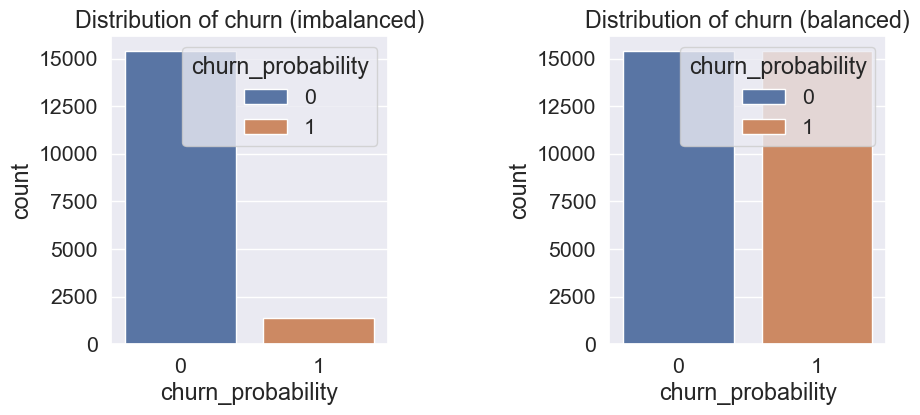

In [912]:
# Checking the distribution on our target variable 'y_train' before and after SMOTE
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.title("Distribution of churn (imbalanced)")
sns.countplot(x=y_train, hue=y_train)

plt.subplot(1,2,2)
plt.title("Distribution of churn (balanced)")
sns.countplot(x=y_train_smote, hue=y_train_smote)

plt.subplots_adjust(wspace=0.8)
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

Now the data imbalance issue is sorted.

### 7.3 Feature Scaling

In [913]:
scaler = StandardScaler()

#### Feature Scaling for Training Set

In [914]:
 # Fit and transform training set
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_smote), columns = X_train_smote.columns, index = X_train_smote.index)

# Only Transform validation set
X_val_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns, index = X_test.index)

In [915]:
X_train_scaled.head()

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
0,0.149095,0.096308,0.612510,-0.131921,-0.127237,0.241261,2.442333,-0.530509,2.266093,2.179345,...,-0.246405,1.498577,-0.209151,-0.882333,-0.208259,1.083555,-0.936624,-0.109314,1.043735,-0.133862
1,-0.011493,0.097476,0.221889,-0.168737,-0.384978,0.112302,0.953740,-0.530509,1.403829,1.516742,...,-0.246405,-0.683643,-0.209151,-0.882333,-0.208259,-0.946637,-0.936624,-0.109314,-0.998620,-0.133862
2,1.347327,1.161152,1.273531,-0.123085,-0.561953,-0.429037,-0.527309,-0.530509,-0.665387,-0.547857,...,-0.246405,-0.683643,-0.209151,-0.882333,-0.208259,-0.946637,-0.936624,-0.109314,-0.998620,-0.133862
3,0.575346,0.440481,0.779008,1.168977,1.270920,1.305695,-0.527309,-0.530509,-0.665387,-0.547857,...,-0.246405,1.498577,-0.209151,1.162058,-0.208259,1.083555,1.104365,-0.109314,1.043735,-0.133862
4,1.177188,1.567876,1.767948,0.643098,-0.114267,0.279907,-0.527309,-0.530509,-0.665387,-0.547857,...,-0.246405,1.498577,-0.209151,1.162058,-0.208259,1.083555,-0.936624,10.125927,-0.998620,8.908799


#### Feature Scaling for Test Set

In [916]:
final_df_unseen.head()

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,...,fb_user_8_0.0,fb_user_8_1.0,fb_user_7_0.0,fb_user_7_1.0,fb_user_6_0.0,fb_user_6_1.0,night_pck_user_7_0.0,night_pck_user_7_1.0,night_pck_user_6_0.0,night_pck_user_6_1.0
0,3.489819,3.055415,3.182627,4.113493,3.501344,3.578786,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.337421,3.742657,3.036874,6.164030,6.434290,5.981263,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.144761,2.181547,2.240710,2.889260,3.846097,3.829511,3.170106,4.648038,3.298795,3.239854,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.842136,1.150572,0.000000,3.714547,5.327925,3.219276,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6.113527,6.413508,6.553477,4.126166,3.212455,4.319619,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [917]:
final_df_unseen.set_index('id', inplace=True)

### 7.4 Model Building

#### Model 1 - Logistic Regression with RFE

In [918]:
%%time
# Select top 20 features using RFE
logreg = LogisticRegression(max_iter=1000, tol=0.001, solver='sag')
rfe = RFE(logreg, n_features_to_select=20)
rfe = rfe.fit(X_train_scaled, y_train_smote)

CPU times: user 3min 50s, sys: 1.11 s, total: 3min 51s
Wall time: 3min 52s


In [919]:
# Selected features using RFE
selected_features = X_train_scaled.columns[rfe.support_]
selected_features

Index(['roam_ic_mou_8', 'roam_og_mou_8', 'loc_ic_t2t_mou_7',
       'loc_ic_t2t_mou_8', 'loc_ic_t2m_mou_7', 'loc_ic_t2m_mou_8',
       'loc_ic_mou_7', 'loc_ic_mou_8', 'spl_ic_mou_8', 'total_ic_mou_8',
       'total_rech_num_7', 'total_rech_num_8', 'total_rech_amt_6',
       'total_rech_amt_8', 'max_rech_amt_6', 'max_rech_amt_8',
       'last_day_rch_amt_8', 'max_rech_data_8', 'count_rech_2g_8',
       'night_pck_user_8_0.0'],
      dtype='object')

In [920]:
X_train_scaled_final = X_train_scaled[selected_features]
logreg.fit(X_train_scaled_final, y_train_smote)

LogisticRegression(max_iter=1000, solver='sag', tol=0.001)

In [921]:
y_train_smote_pred = logreg.predict(X_train_scaled_final)

In [922]:
# Calculate metrics on the training set
calculate_classification_metrics(y_train_smote, y_train_smote_pred)

Confusion Matrix

[[13532  1868]
 [ 2540 12860]]


,Metric,Value
0,Accuracy,0.8569
1,Sensitivity,0.8351
2,Specificity,0.8787
3,Precision,0.8732
4,False Positive Rate,0.1213
5,True Positive Rate,0.8351


In [923]:
# Retain only the selected feature from the final model
X_val_scaled_final = X_val_scaled[selected_features]
X_val_scaled_final.head()

,roam_ic_mou_8,roam_og_mou_8,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_mou_7,loc_ic_mou_8,spl_ic_mou_8,total_ic_mou_8,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_8,max_rech_amt_6,max_rech_amt_8,last_day_rch_amt_8,max_rech_data_8,count_rech_2g_8,night_pck_user_8_0.0
3837,-0.665387,-0.710456,-0.630123,-0.290162,-1.557467,-0.780543,-1.260504,-0.619065,-0.266206,-0.300154,-1.082799,-0.101475,0.204074,0.547510,0.794832,0.902878,-1.039975,1.790895,-0.595224,1.363391
11055,-0.665387,-0.710456,-1.797890,-1.503512,-2.375165,-1.877598,-2.594405,-1.984776,2.474225,-1.317514,-1.434322,-0.619858,0.035264,0.561889,0.794832,0.902878,-1.039975,1.790895,-0.595224,1.363391
12221,-0.665387,-0.710456,-0.936447,0.500098,-1.291167,-0.008028,-1.288234,0.116256,6.933130,0.329095,0.159277,1.437791,-5.086412,0.669800,-4.510459,0.156583,0.724532,-0.735593,-0.595224,-0.759323
17179,0.507003,0.310656,-1.797890,-1.503512,-2.375165,-1.877598,-2.594405,-1.984776,-0.266206,-1.395256,0.159277,-0.101475,0.347429,-0.539241,0.004934,-0.256881,-1.039975,-0.735593,-0.595224,-0.759323
16047,-0.665387,-0.710456,1.009885,1.293738,0.136624,0.558736,0.498657,0.815104,-0.266206,0.859190,-1.887514,-0.987657,0.431105,-1.678770,1.078205,-1.675565,-1.039975,-0.735593,-0.595224,-0.759323


In [924]:
# Get the predicted values from the linear model
y_val_pred = logreg.predict(X_val_scaled_final)

In [925]:
confusion = confusion_matrix(y_true=y_test, y_pred=y_val_pred)
print(confusion)

[[3379  484]
 [  76  261]]


In [926]:
# Calculate metrics
metrics_df = calculate_classification_metrics(y_true=y_test, y_pred=y_val_pred)
metrics_df

Confusion Matrix

[[3379  484]
 [  76  261]]


,Metric,Value
0,Accuracy,0.8667
1,Sensitivity,0.7745
2,Specificity,0.8747
3,Precision,0.3503
4,False Positive Rate,0.1253
5,True Positive Rate,0.7745


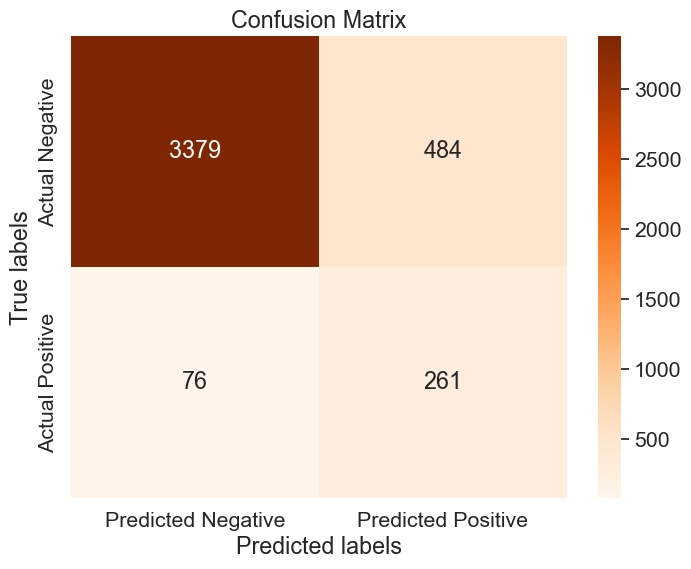

In [927]:
# Define labels for the confusion matrix
labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']

# Reshape the confusion matrix into a 2x2 array
cm_array = np.array(confusion).reshape(2,2)

# Create the heatmap
plt.figure(figsize=(8,6))
sns.set(font_scale=1.4)
sns.heatmap(cm_array, annot=True, cmap='Oranges', fmt='g', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

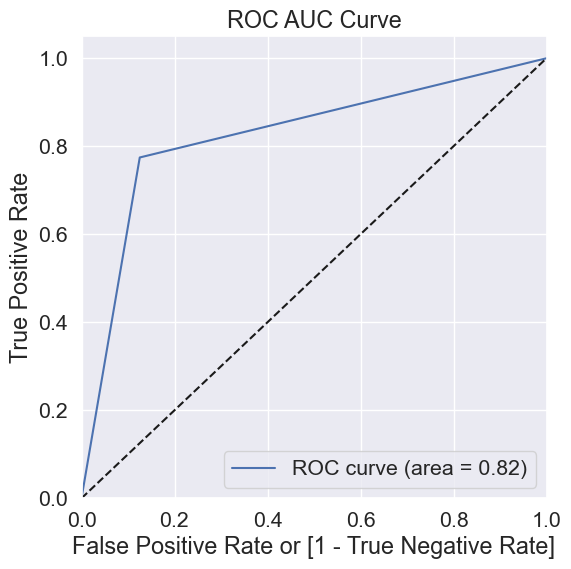

In [928]:

# ROC curve
fpr, tpr, thresholds = draw_roc(y_test, y_val_pred)

In [929]:
# ROC AUC Score
"{:2.2f}".format(roc_auc_score(y_test, y_val_pred))

'0.82'

#### Model 2 - Logistic Regression with PCA and Hyperparameter Tuning

In [930]:
pca = PCA()

In [931]:
pca_components = pca.fit_transform(X_train)
pca_components

array([[ 4.89135055e-01,  2.83721156e+00,  3.62021401e+00, ...,
         3.28530435e-15, -4.74127258e-15,  1.53545872e-14],
       [ 6.47598780e+00, -4.59803150e+00, -1.14579551e+00, ...,
         5.01991219e-16, -1.36763714e-14,  3.00187684e-14],
       [ 1.19215807e+01, -4.15662423e+00,  2.45699559e+00, ...,
         5.91498070e-15, -1.05863123e-14, -2.00689482e-15],
       ...,
       [-3.92522050e+00,  3.86954317e+00, -2.86308492e-01, ...,
        -1.20357734e-14,  1.69802096e-15, -2.48617639e-15],
       [-1.23247013e+01, -8.91514399e-01, -1.74474951e+00, ...,
        -3.26501150e-15, -5.74047330e-15, -6.91319070e-15],
       [-2.52714922e+01, -4.94115360e+00,  6.79133427e+00, ...,
        -2.56915166e-14,  7.58220299e-15, -5.69842491e-14]])

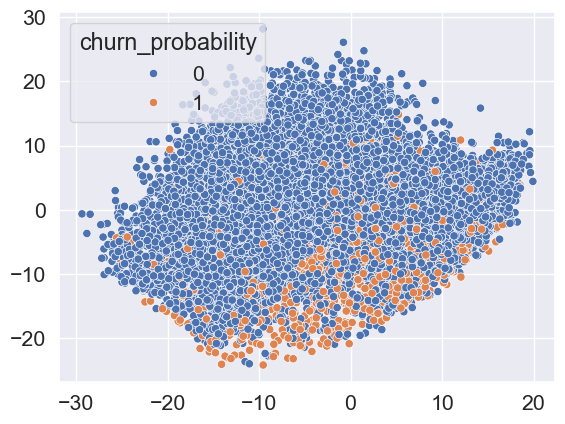

In [932]:
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1], hue=y_train)
plt.show()

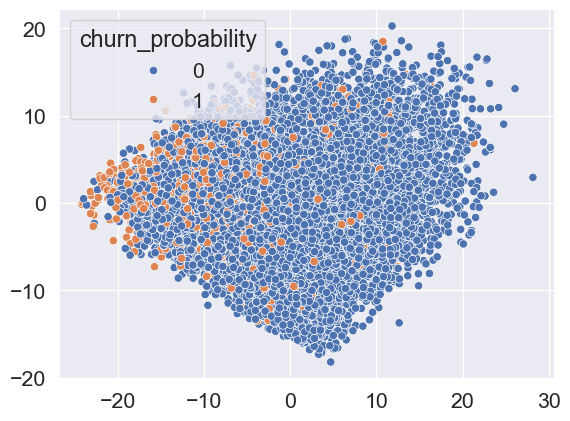

In [933]:
sns.scatterplot(x=pca_components[:,1], y=pca_components[:,2], hue=y_train)
plt.show()

<div class="alert alert-block alert-info">
<h4>Analysis:</h4>

* As we can see, there is a clear class imbalance and we have addressed this below using SMOTE


In [934]:
X = high_value_customer.copy().drop(['churn_probability'], axis=1)
y = high_value_customer.copy()['churn_probability']

In [935]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=100)

In [936]:
imputer = SimpleImputer(strategy='constant', fill_value=0)
scaler = StandardScaler()
pca = PCA(n_components=20)
smote = SMOTE(random_state=2)
lr = LogisticRegression(max_iter=1000, tol=0.001, random_state=42)

In [937]:
pipe = make_pipeline(
    imputer,
    smote,
    scaler,
    pca,
    lr
)

In [938]:
# Define hyperparameters grid for GridSearchCV
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__solver': ['liblinear', 'saga'],
}

In [939]:
# Instantiate GridSearchCV
lr_grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [940]:
# Fit the model using GridSearchCV
lr_grid_search.fit(X_train, y_train)

# Get the best parameters and estimator
lr_best_params = lr_grid_search.best_params_
lr_best_estimator = lr_grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

In [941]:
# Predict values on the training set
y_train_pred = lr_grid_search.predict(X_train)

In [942]:
# Predict values on the validation set
y_val_pred = lr_grid_search.predict(X_val)

In [943]:
# Metrics of the training set
calculate_classification_metrics(y_train, y_train_pred)

Confusion Matrix

[[12478  2922]
 [  277  1121]]


,Metric,Value
0,Accuracy,0.8096
1,Sensitivity,0.8019
2,Specificity,0.8103
3,Precision,0.2773
4,False Positive Rate,0.1897
5,True Positive Rate,0.8019


In [944]:
# Metrics of the validation set
calculate_classification_metrics(y_val, y_val_pred)

Confusion Matrix

[[3141  722]
 [  77  260]]


,Metric,Value
0,Accuracy,0.8098
1,Sensitivity,0.7715
2,Specificity,0.8131
3,Precision,0.2648
4,False Positive Rate,0.1869
5,True Positive Rate,0.7715


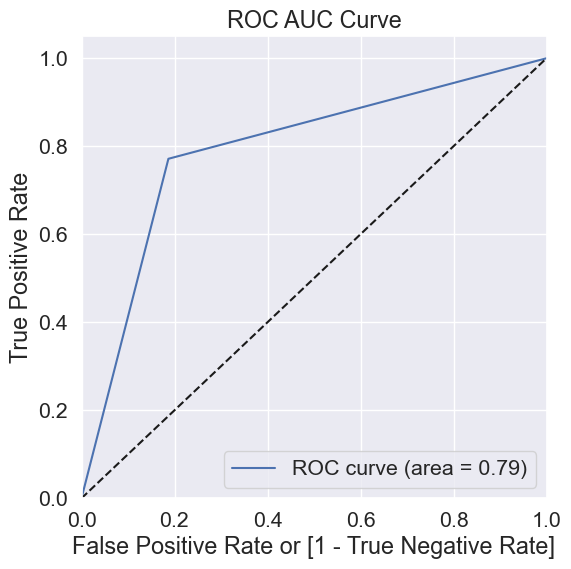

In [945]:
# ROC curve
fpr, tpr, thresholds = draw_roc(y_val, y_val_pred)

#### Model 3 - Decision Tree with PCA and GridSearchCV

In [946]:
dt = DecisionTreeClassifier(random_state=42)

In [947]:
imputer = SimpleImputer(strategy='constant', fill_value=0)
scaler = StandardScaler()
pca = PCA(n_components=25)
smote = SMOTE(random_state=2)

In [948]:
# Create a pipeline
pipe = make_pipeline(
    imputer,
    smote,
    scaler,
    pca,
    dt
)

In [949]:
# Create the parameter grid based on the results of random search 
params = {
    'decisiontreeclassifier__max_depth': [2, 3, 5, 10, 20],
    'decisiontreeclassifier__min_samples_leaf': [5, 10, 20, 50, 100],
}

In [950]:
# Instantiate the grid search model
grid_search = GridSearchCV(estimator=pipe, 
                           param_grid=params, 
                           cv=5, n_jobs=-1, verbose=1, scoring = "accuracy")

In [951]:
# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer',
                                        SimpleImputer(fill_value=0,
                                                      strategy='constant')),
                                       ('smote', SMOTE(random_state=2)),
                                       ('standardscaler', StandardScaler()),
                                       ('pca', PCA(n_components=25)),
                                       ('decisiontreeclassifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'decisiontreeclassifier__max_depth': [2, 3, 5, 10, 20],
                         'decisiontreeclassifier__min_samples_leaf': [5, 10, 20,
                                                                      50,
                                                                      100]},
             scoring='accuracy', verbose=1)

In [952]:
# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Predict on train set using the best model
y_train_pred = grid_search.predict(X_train)

# Predict on validation set using the best model
y_val_pred = grid_search.predict(X_val)

In [953]:
# Metrics on the train set
calculate_classification_metrics(y_train, y_train_pred)

Confusion Matrix

[[14670   730]
 [   71  1327]]


,Metric,Value
0,Accuracy,0.9523
1,Sensitivity,0.9492
2,Specificity,0.9526
3,Precision,0.6451
4,False Positive Rate,0.0474
5,True Positive Rate,0.9492


In [954]:
# Metrics on the validation set
calculate_classification_metrics(y_val, y_val_pred)

Confusion Matrix

[[3297  566]
 [ 154  183]]


,Metric,Value
0,Accuracy,0.8286
1,Sensitivity,0.5430
2,Specificity,0.8535
3,Precision,0.2443
4,False Positive Rate,0.1465
5,True Positive Rate,0.5430


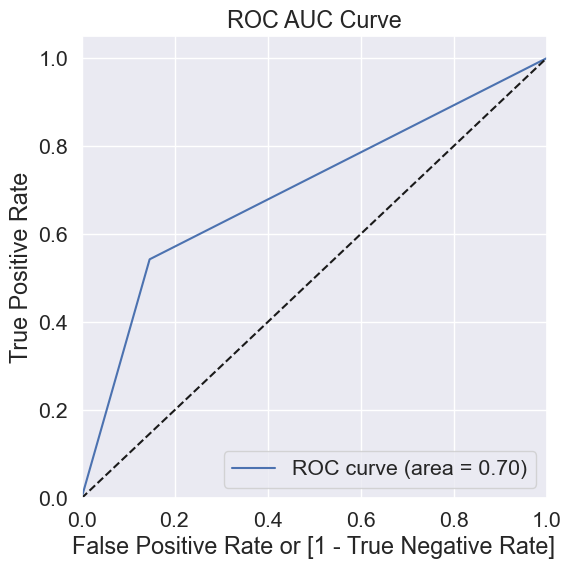

In [955]:
# ROC curve
fpr, tpr, thresholds = draw_roc(y_val, y_val_pred)

#### Model 4 - Random Forest Classifier with PCA and Hyperparameter Tuning

In [956]:
rf = RandomForestClassifier(random_state=42)

In [957]:
# Create a pipeline
pipe = make_pipeline(
    imputer,
    smote,
    scaler,
    pca,
    rf
)

In [958]:
# Define the hyperparameters grid for Random Forest
param_grid = {
    'randomforestclassifier__n_estimators': [100],  
    'randomforestclassifier__max_depth': [5, 10],       
    'randomforestclassifier__min_samples_split': [2, 5, 10],
}

In [959]:
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [960]:
%%time
# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
CPU times: user 9.45 s, sys: 225 ms, total: 9.67 s
Wall time: 35.6 s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer',
                                        SimpleImputer(fill_value=0,
                                                      strategy='constant')),
                                       ('smote', SMOTE(random_state=2)),
                                       ('standardscaler', StandardScaler()),
                                       ('pca', PCA(n_components=25)),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [5, 10],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [100]},
             scoring='accuracy', verbose=1)

In [961]:
# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best model
best_model = grid_search.best_estimator_

# Predict on train set using the best model
y_train_pred = best_model.predict(X_train)

# Predict on train set using the validation model
y_test_pred = best_model.predict(X_val)

Best Parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 100}


In [962]:
# Metrics on the train set
calculate_classification_metrics(y_train, y_train_pred)

Confusion Matrix

[[13955  1445]
 [   80  1318]]


,Metric,Value
0,Accuracy,0.9092
1,Sensitivity,0.9428
2,Specificity,0.9062
3,Precision,0.4770
4,False Positive Rate,0.0938
5,True Positive Rate,0.9428


In [963]:
# Metrics on the validation set
calculate_classification_metrics(y_val, y_val_pred)

Confusion Matrix

[[3297  566]
 [ 154  183]]


,Metric,Value
0,Accuracy,0.8286
1,Sensitivity,0.5430
2,Specificity,0.8535
3,Precision,0.2443
4,False Positive Rate,0.1465
5,True Positive Rate,0.5430


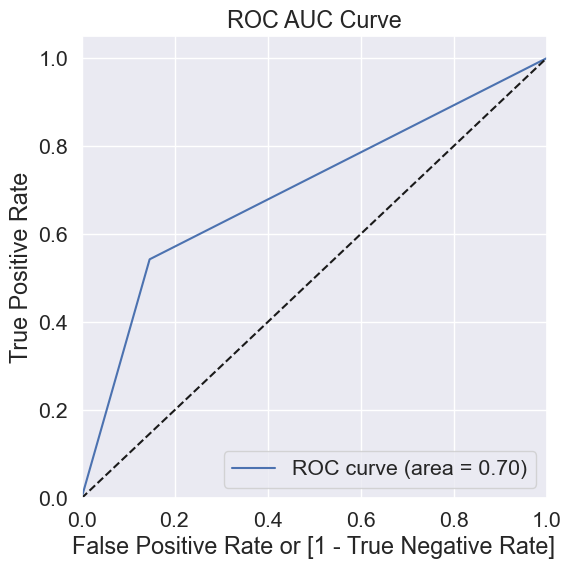

In [964]:
# ROC curve
fpr, tpr, thresholds = draw_roc(y_val, y_val_pred)

#### Model 5 - XGBoost Classifier

In [965]:
# Create a pipeline
pipe = make_pipeline(
    imputer,
    smote,
    scaler,
    pca,
    XGBClassifier(random_state=42)
)

In [966]:
# Define hyperparameters for grid search
param_grid = {
    'xgbclassifier__n_estimators': [100, 200, 300],  
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.3]
}

In [967]:
# Instantiate GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [968]:
%%time
# Train the model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
CPU times: user 3.94 s, sys: 1.24 s, total: 5.18 s
Wall time: 22 s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer',
                                        SimpleImputer(fill_value=0,
                                                      strategy='constant')),
                                       ('smote', SMOTE(random_state=2)),
                                       ('standardscaler', StandardScaler()),
                                       ('pca', PCA(n_components=25)),
                                       ('xgbclassifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      d...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'xgbclassifier__learning_rate': [0.01, 0.1, 0.3],
                         'xgbclassifier__max_depth': [3, 5, 7],
                         'xgbclassifier__n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [969]:
# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best model
best_model = grid_search.best_estimator_

# Predict on train set using the best model
y_train_pred = best_model.predict(X_train)

# Predict on train set using the validation model
y_test_pred = best_model.predict(X_val)

Best Parameters: {'xgbclassifier__learning_rate': 0.3, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 300}


In [970]:
# Metrics on the train set
calculate_classification_metrics(y_train, y_train_pred)

Confusion Matrix

[[15400     0]
 [    0  1398]]


,Metric,Value
0,Accuracy,1.0
1,Sensitivity,1.0
2,Specificity,1.0
3,Precision,1.0
4,False Positive Rate,0.0
5,True Positive Rate,1.0


In [971]:
# Metrics on the validation set
calculate_classification_metrics(y_val, y_val_pred)

Confusion Matrix

[[3297  566]
 [ 154  183]]


,Metric,Value
0,Accuracy,0.8286
1,Sensitivity,0.5430
2,Specificity,0.8535
3,Precision,0.2443
4,False Positive Rate,0.1465
5,True Positive Rate,0.5430


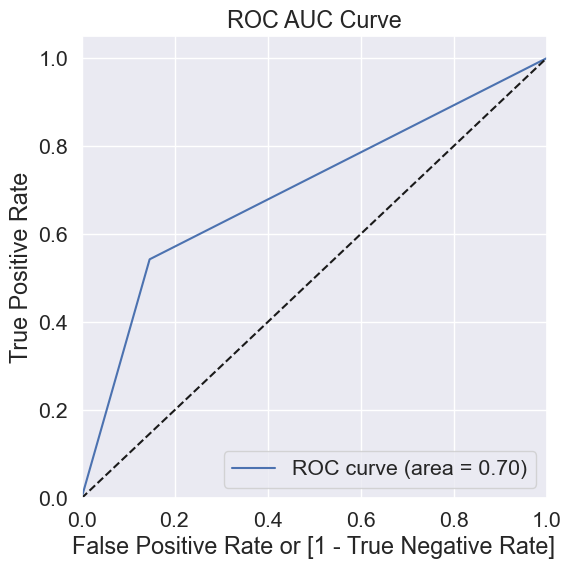

In [972]:
# ROC curve
fpr, tpr, thresholds = draw_roc(y_val, y_val_pred)

#### Model 6 - Adaboost Classifier

In [973]:
# Create a pipeline
pipe = make_pipeline(
    imputer,
    smote,
    scaler,
    pca,
    AdaBoostClassifier(n_estimators=200, random_state=42)
)

In [974]:
# Build the model
adaboost_model = pipe.fit(X_train, y_train)

/Users/rajak/Workstation/Projects/myGitHub/LearnAIML/env/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [975]:
# Predict on train set using the best model
y_train_pred = adaboost_model.predict(X_train)

# Predict on train set using the validation model
y_test_pred = adaboost_model.predict(X_val)

In [976]:
# Metrics on the train set
calculate_classification_metrics(y_train, y_train_pred)

Confusion Matrix

[[12959  2441]
 [  285  1113]]


,Metric,Value
0,Accuracy,0.8377
1,Sensitivity,0.7961
2,Specificity,0.8415
3,Precision,0.3132
4,False Positive Rate,0.1585
5,True Positive Rate,0.7961


In [977]:
# Metrics on the validation set
calculate_classification_metrics(y_val, y_val_pred)

Confusion Matrix

[[3297  566]
 [ 154  183]]


,Metric,Value
0,Accuracy,0.8286
1,Sensitivity,0.5430
2,Specificity,0.8535
3,Precision,0.2443
4,False Positive Rate,0.1465
5,True Positive Rate,0.5430


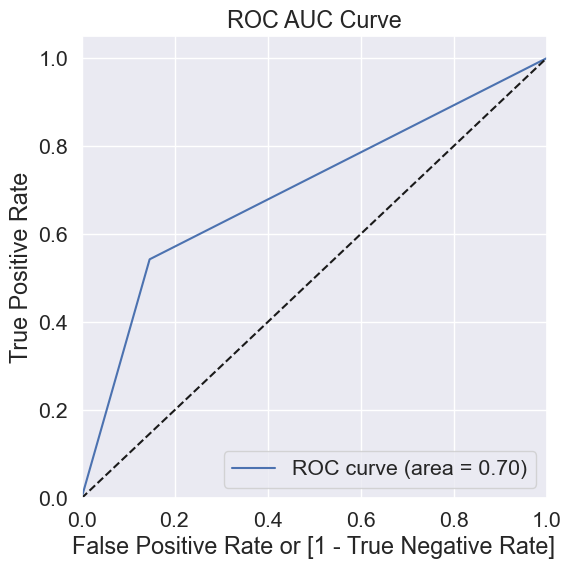

In [978]:
# ROC curve
fpr, tpr, thresholds = draw_roc(y_val, y_val_pred)

## 8. Create submission.csv file

In [979]:
submission_data = final_df_unseen[selected_features]
submission_data.shape

(30000, 20)

In [980]:
final_df_unseen['churn_probability'] = logreg.predict(submission_data)
output = final_df_unseen[['churn_probability']]
output

/var/folders/q2/0276zgxs0m7bj83vqzpkxlqh0000gn/T/ipykernel_26862/3362250833.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df_unseen['churn_probability'] = logreg.predict(submission_data)


,churn_probability
id,
69999,0
70000,0
70001,1
70002,0
70003,0
...,...
99994,0
99995,0
99996,0


In [981]:
output.to_csv('submission.csv', index=True)

## 9. Summary

1. Experimented Models:
    * Various models were tested, including Logistic Regression (with and without Recursive Feature Elimination), PCA, Decision Tree, Random Forest, Adaboost, and XGBoost classifiers.

2. Performance Evaluation:
    * Logistic Regression combined with PCA consistently demonstrated the highest sensitivity across both the training and validation datasets.

3. Model Selection:
    * Logistic Regression with PCA was identified as the most reliable model due to its balanced performance and generalization capability.

4. Overfitting in Other Models:
    * Other models, such as Decision Tree, Random Forest, Adaboost, and XGBoost, displayed promising accuracy during the training phase but performed poorly on the test dataset, indicating overfitting.

5. **Final Recommendation**:
    * Logistic Regression with PCA is recommended as the final model for deployment due to its robustness and superior sensitivity metrics.

## 10. Business Recommendations

1. High-Value Recharge Incentives: Introduce discounts and benefits for high-value recharges to retain high-spending customers.
2. Data Recharge Strategies: Launch targeted marketing campaigns to promote data packs and boost data usage.
3. Roaming Offers: Provide personalized roaming packages tailored to frequent roamers to encourage loyalty.
4. Local Call Promotions: Offer competitive rates and bonuses for local calls to meet customer needs and increase satisfaction.
5. Retention Campaigns: Focus on customers with low recharge activity by offering them special discounts and plans.

By implementing these strategies, the telecom business can effectively reduce churn and improve customer retention.